<a id='0'></a>
## Introduzione

L'obiettivo di questo notebook è quello di sviluppare un Recommender System sulla base del dataset MovieLens 100K
https://files.grouplens.org/datasets/movielens/ml-100k.

Il codice è suddiviso nelle seguenti parti:
1. [Librerie utilizzate](#1)

2. [Importazione e preparazione datasets](#2)

3. [Statistiche descrittive](#3)

4. [Filling della matrice di rating](#4)
    - KNN con Cosine Similarity
    - KNN con Pearson Correlation
    - SVD
    
    
5. [Confronto delle performance](#5)

6. [Rappresentazione matrice](#6)

7. [K-Means clustering](#7)


<a id='1'></a>
___

## Librerie utilizzate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as plt_colors
import matplotlib.cm as plt_cm
import squarify
from tabulate import tabulate
from pywaffle import Waffle
import seaborn as sns
import plotly.graph_objects as go
import pgeocode

# filling rating matrix
from surprise import Reader, Dataset, KNNBasic, SVD
from surprise.model_selection import cross_validate
from surprise import accuracy
from surprise.model_selection import KFold

# kmeans cluster
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.metrics import silhouette_score

# plot rating matrix
from sklearn.metrics import pairwise_distances
import itertools
import networkx as nx

import csv

<a id='2'></a>
___

## Importazione e preparazione datasets
[Indice](#0)

In [2]:
url_data = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.data'
url_item = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.item'
url_user = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.user'

In [3]:
ratings = pd.read_csv(url_data, sep='\t', header=None, encoding='latin-1')
ratings.columns = ['user_id', 'movie_id', 'rating', 'timestamp']
users = pd.read_csv(url_user, sep='|', header=None, encoding='latin-1')
users.columns = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
items = pd.read_csv(url_item, sep='|', header=None, encoding='latin-1')
items.columns = ['movie_id', 'movie_title', 'release_date', 'video_release_date', 'imdb_url', 'other', 
                 'action', 'adventure', 'animation', 'children', 'comedy', 'crime', 'documentary', 
                 'drama', 'fantasy', 'noir', 'horror', 'musical', 'mystery', 'romance', 'sci-fi', 
                 'thriller', 'war', 'western']

#### Dataset: items


Il dataset items è composto da 1682 osservazioni con 23 attributi ciascuna.

In [4]:
items.info()
items.describe()
items.head()
items.tail()
items.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_id            1682 non-null   int64  
 1   movie_title         1682 non-null   object 
 2   release_date        1681 non-null   object 
 3   video_release_date  0 non-null      float64
 4   imdb_url            1679 non-null   object 
 5   other               1682 non-null   int64  
 6   action              1682 non-null   int64  
 7   adventure           1682 non-null   int64  
 8   animation           1682 non-null   int64  
 9   children            1682 non-null   int64  
 10  comedy              1682 non-null   int64  
 11  crime               1682 non-null   int64  
 12  documentary         1682 non-null   int64  
 13  drama               1682 non-null   int64  
 14  fantasy             1682 non-null   int64  
 15  noir                1682 non-null   int64  
 16  horror

,movie_id,movie_title,release_date,video_release_date,imdb_url,other,action,adventure,animation,children,...,fantasy,noir,horror,musical,mystery,romance,sci-fi,thriller,war,western
212,213,"Room with a View, A (1986)",01-Jan-1986,NaN,http://us.imdb.com/M/title-exact?Room%20with%2...,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1107,1108,Feast of July (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Feast%20of%20...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
82,83,Much Ado About Nothing (1993),01-Jan-1993,NaN,http://us.imdb.com/M/title-exact?Much%20Ado%20...,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
119,120,Striptease (1996),28-Jun-1996,NaN,http://us.imdb.com/M/title-exact?Striptease%20...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1213,1214,In the Realm of the Senses (Ai no corrida) (1976),08-Mar-1976,NaN,http://us.imdb.com/M/title-exact?Ai%20no%20Cor...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Verifico la presenza di valori nan e risolvo nei seguenti modi:

In [5]:
items.isna().sum()

movie_id                 0
movie_title              0
release_date             1
video_release_date    1682
imdb_url                 3
other                    0
action                   0
adventure                0
animation                0
children                 0
comedy                   0
crime                    0
documentary              0
drama                    0
fantasy                  0
noir                     0
horror                   0
musical                  0
mystery                  0
romance                  0
sci-fi                   0
thriller                 0
war                      0
western                  0
dtype: int64

1. Pulisco l'attributo movie title e sposto l'informazione dell'anno nell'attributo video_release_date

In [6]:
items['video_release_date'] = items['movie_title'].apply(lambda x: str(x)[-7:])
items['video_release_date'] = items['video_release_date'].apply(lambda x: str(x).replace("(", ""))
items['video_release_date'] = items['video_release_date'].apply(lambda x: str(x).replace(")", ""))
items['video_release_date'] = items['video_release_date'].apply(lambda x: str(x).replace(" ", ""))
items['movie_title'] = items['movie_title'].apply(lambda x: str(x)[:-7])

2. Verifico la row con release date nan, decido di droppare la row

In [7]:
items[items['release_date'].isna() == True]
items[items['movie_title'] == 'unknown']
items.drop(items[items['release_date'].isna() == True].index, axis=0, inplace=True)

3. Verifico le due row con imdb_url none, noto che i valori non sono utili (url non più validi). Decido di droppare l'intera colonna

In [8]:
items[items['imdb_url'].isna() == True]
items[items['imdb_url'].isna() == False]['imdb_url'][0]
items.drop('imdb_url', axis=1, inplace=True)

#### Dataset: users

Il dataset items è composto da 943 osservazioni con 5 attributi ciascuna.

Verifico la presenza di valori nan e noto che non ne esistono

In [9]:
users.info()
users.describe()
users.head()
users.tail()
users.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     943 non-null    int64 
 1   age         943 non-null    int64 
 2   gender      943 non-null    object
 3   occupation  943 non-null    object
 4   zip_code    943 non-null    object
dtypes: int64(2), object(3)
memory usage: 37.0+ KB


,user_id,age,gender,occupation,zip_code
845,846,27,M,lawyer,47130
411,412,25,M,educator,15222
58,59,49,M,educator,08403
115,116,40,M,healthcare,97232
26,27,40,F,librarian,30030


In [10]:
users.isna().sum()

user_id       0
age           0
gender        0
occupation    0
zip_code      0
dtype: int64

#### Dataset: ratings

Il dataset items è composto da 100000 osservazioni con 4 attributi ciascuna.

In [11]:
ratings.info()
ratings.describe()
ratings.head()
ratings.tail()
ratings.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


,user_id,movie_id,rating,timestamp
68865,868,240,5,877107373
62909,761,326,1,876189715
83060,788,649,3,880869649
13103,43,175,2,875981304
75105,628,690,5,880776981


Verifico la presenza di valori nan e noto che non ne esistono

In [12]:
ratings.isna().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

#### Merged dataset

In [13]:
dataset = pd.merge(ratings, users, on='user_id')
dataset = pd.merge(dataset, items, on='movie_id')

<a id='3'></a>
___

## Statistiche Descrittive
[Indice](#0)

#### Dataset: items

Quali sono i generi più diffusi?
Noto che i generi più diffusi sono: 
1. Drama
2. Comedy
3. Action
4. Thriller
5. Romance

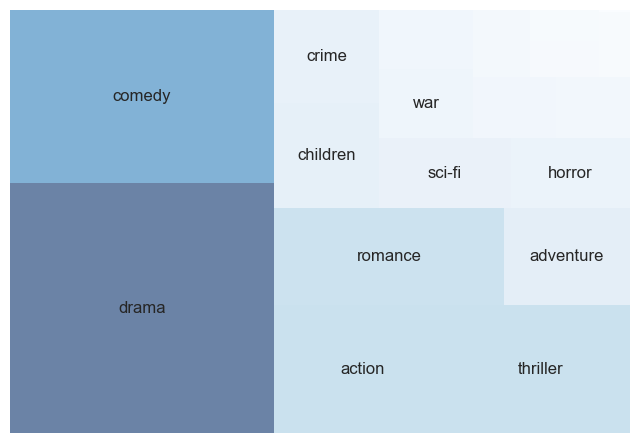

In [14]:
sums = items.drop('movie_id', axis=1).select_dtypes(np.number).sum()
item_per_genre = pd.DataFrame({'genre': sums.index.values, 'count': sums.values.astype(int)})
item_per_genre = item_per_genre.sort_values(by='count', ascending=False)
cmap = plt_cm.Blues
mini = min(item_per_genre['count'])
maxi = max(item_per_genre['count'])
norm = plt_colors.Normalize(vmin=mini, vmax=maxi)
colors = [cmap(norm(value)) for value in item_per_genre['count']]
squarify.plot(sizes=item_per_genre['count'], label=item_per_genre['genre'][:11], color=colors, alpha=0.6)
plt.axis('off')
plt.show()

#### Dataset: users

Com'è distributito il campione degli utenti in base al genere?

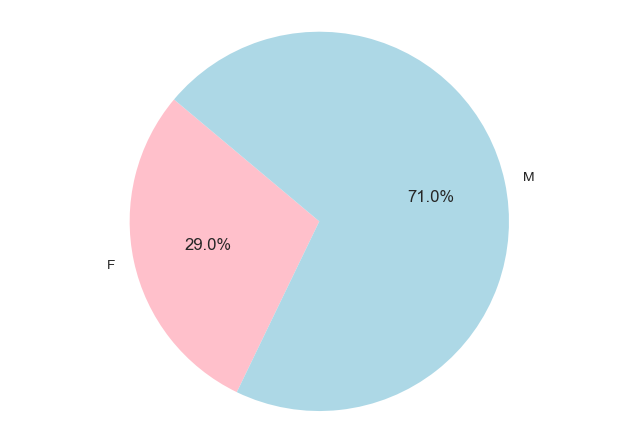

In [15]:
users[users['gender'] == 'F'].count().user_id
# pie plot
labels = ['F', 'M']
sizes = [users[users['gender'] == 'F'].count().user_id, users[users['gender'] == 'M'].count().user_id]
colors = ['pink', 'lightblue']
explode = (0, 0)

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', 
         shadow=False, startangle=140)

plt.axis('equal')
plt.show()

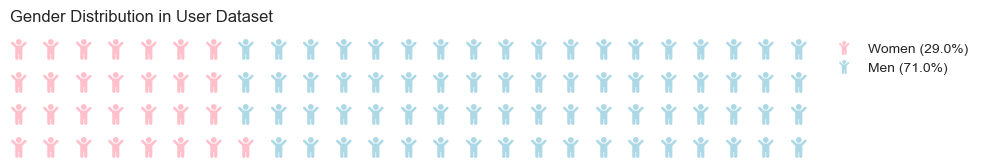

In [16]:
tot = len(users)
data_aux = {'Women': np.ceil((users[users['gender'] == 'F'].count().user_id)/tot*100),
        'Men': np.floor((users[users['gender'] == 'M'].count().user_id)/tot*100)}
fig = plt.figure(
    FigureClass=Waffle, 
    rows=4, 
    values=data_aux, 
    colors=("pink", "lightblue"),
    title={'label': 'Gender Distribution in User Dataset', 'loc': 'left'},
    labels=["{0} ({1}%)".format(k, v) for k, v in data_aux.items()],
    # legend={'loc': 'lower left', 'bbox_to_anchor': (0, -0.4), 'ncol': len(data), 'framealpha': 0},
    legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
    icons='child', icon_size=15, 
    icon_legend=True,
    figsize=(10, 15)
)
fig.gca().set_facecolor('white')
fig.set_facecolor('white')
plt.show()

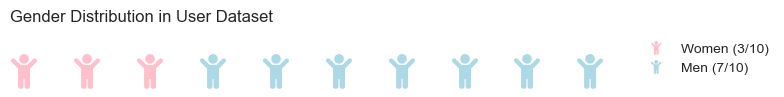

In [17]:
data = {'Women': np.ceil((users[users['gender'] == 'F'].count().user_id)/tot*100*0.1),
        'Men': np.floor((users[users['gender'] == 'M'].count().user_id)/tot*100*0.1)}
fig = plt.figure(
    FigureClass=Waffle, 
    rows=1, 
    values=data, 
    colors=("pink", "lightblue"),
    title={'label': 'Gender Distribution in User Dataset', 'loc': 'left'},
    labels=["{0} ({1}/10)".format(k, int(v)) for k, v in data.items()],
    # legend={'loc': 'lower left', 'bbox_to_anchor': (0, -0.4), 'ncol': len(data), 'framealpha': 0},
    legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
    icons='child', icon_size=25, 
    icon_legend=True,
    figsize=(8, 12)
)
fig.gca().set_facecolor('white')
fig.set_facecolor('white')
plt.show()

In [18]:
# anche nell'espressione dei voti la percentuale è la stessa
dataset.groupby('gender').count()['user_id']

gender
F    25738
M    74253
Name: user_id, dtype: int64

Quali sono le occupazioni più gettonate nel campione?

In [19]:
occupations = np.unique(users.occupation)
occurrences = []
for occ in occupations:
    c = users[users['occupation']==occ].count().user_id
    occurrences.append(c)

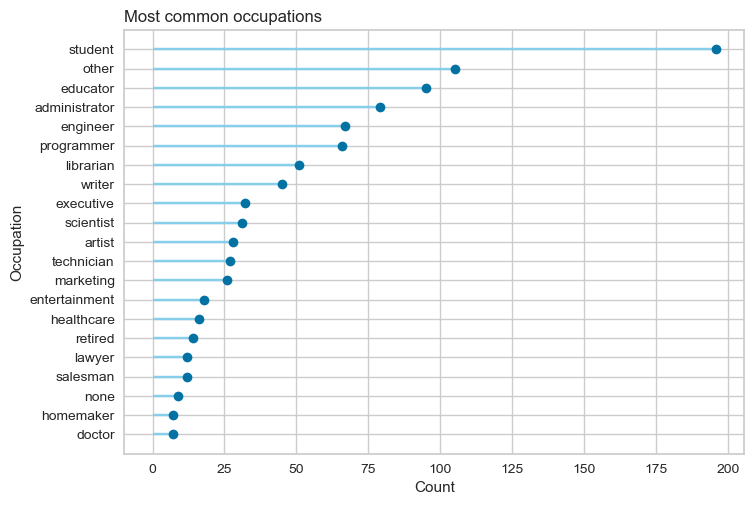

In [20]:
# plot occupation using lollipop 
user_per_occ = pd.DataFrame({'group': np.unique(users.occupation), 'values': occurrences})
 
# ordino per count
user_per_occ = user_per_occ.sort_values(by='values')
my_range=range(1,len(user_per_occ.index)+1)
 
# plotto linee orizzontali
plt.hlines(y=my_range, xmin=0, xmax=user_per_occ['values'], color='skyblue')
plt.plot(user_per_occ['values'], my_range, "o")
 
plt.yticks(my_range, user_per_occ['group'])
plt.title("Most common occupations", loc='left')
plt.xlabel('Count')
plt.ylabel('Occupation')

plt.show()

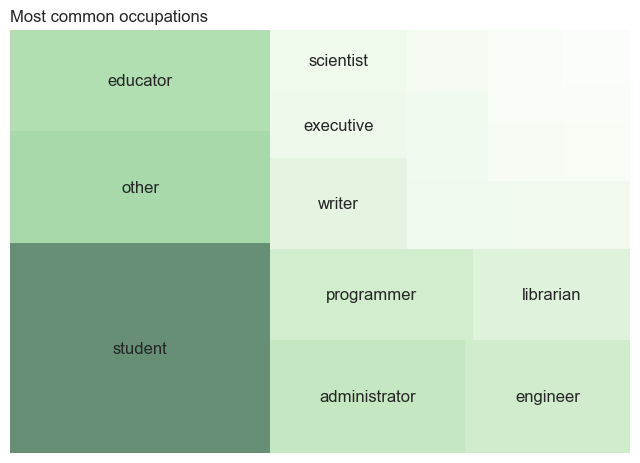

In [21]:
# treemap
user_per_occ = user_per_occ.sort_values(by='values', ascending=False)
cmap = plt_cm.Greens
mini = min(user_per_occ['values'])
maxi = max(user_per_occ['values'])
norm = plt_colors.Normalize(vmin=mini, vmax=maxi)
colors = [cmap(norm(value)) for value in user_per_occ['values']]

squarify.plot(sizes=user_per_occ['values'], label=user_per_occ['group'][:10], color=colors, alpha=0.6)

plt.title("Most common occupations", loc='left')
plt.axis('off')
plt.show()

Com'è distribuita l'età?

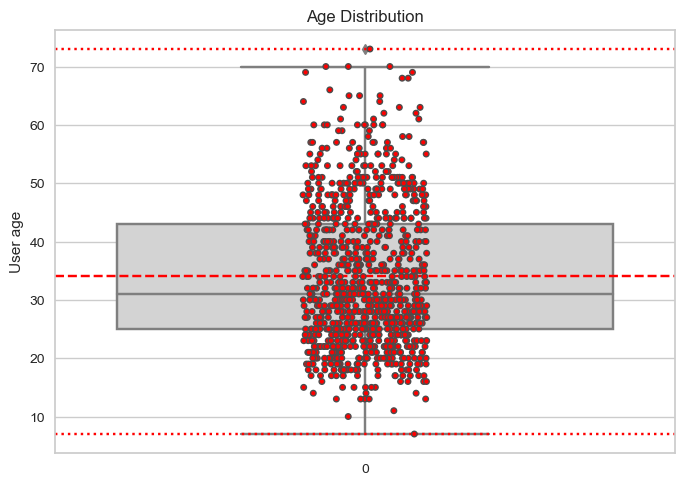

In [22]:
# plotto age
plt.figure()
bp = sns.boxplot(data=users, y="age", color="lightgrey")
sns.stripplot(data=users.age, size=4, color="red", linewidth=1)
oldest = bp.axhline(users['age'].max(), color='red', ls=':', label=users['age'].max()) 
youngest = bp.axhline(users['age'].min(), color='red', ls=':', label=users['age'].min())
mean = bp.axhline(users['age'].mean(), color='red', ls='--', label=users['age'].mean())

plt.title("Age Distribution")
plt.ylabel("User age")
plt.show()

Com'è distribuita l'età in base al genere?

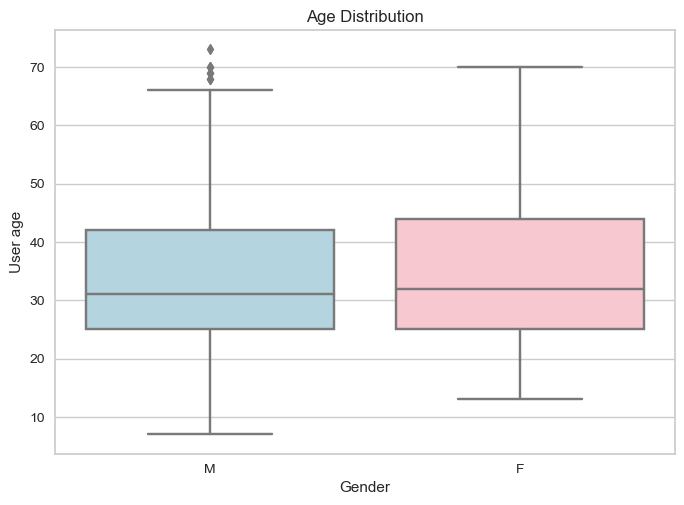

In [23]:
plt.figure()
palette = {
    "F": "pink",
    "M": "lightblue"
}

sns.boxplot(x='gender', y='age', orient='v', data=users, palette=palette)

plt.title("Age Distribution")
plt.ylabel("User age")
plt.xlabel("Gender")
plt.show()

Distribuzione geografica del campione?

In [24]:
df_geo = pd.DataFrame({
    'user_id': users.user_id,
    'zipcode': users.zip_code,
})

nomi = pgeocode.Nominatim('us')

df_geo['latitude'] = (nomi.query_postal_code(df_geo['zipcode'].tolist()).latitude)
df_geo['longitude'] = (nomi.query_postal_code(df_geo['zipcode'].tolist()).longitude)

fig = go.Figure(data=go.Scattergeo(
    lon=df_geo['longitude'],
    lat=df_geo['latitude'],
    mode='markers',
    marker_color='red',
))

fig.update_layout(title='Geographical Distribution', geo_scope='world')
fig.show()

#### Dataset: ratings

Prima di effettuare le analisi mergio il dataset con gli altri due

In [25]:
ratings_merged = pd.merge(ratings, users, on='user_id')
ratings_merged = pd.merge(ratings_merged, items, on='movie_id')

Quali sono i top 10 movies per views?

In [26]:
most_viewed = ratings_merged.groupby('movie_title').count().user_id.sort_values(ascending=False)
most_viewed[:10]

movie_title
Star Wars                 583
Contact                   509
Fargo                     508
Return of the Jedi        507
Liar Liar                 485
English Patient, The      481
Scream                    478
Toy Story                 452
Air Force One             431
Independence Day (ID4)    429
Name: user_id, dtype: int64

Quali sono i top 10 movies per media con views > 300?

In [27]:
most_rated = ratings_merged.groupby('movie_title').mean().rating.sort_values(ascending=False)
most_rated_and_viewed = pd.merge(most_viewed, most_rated, on='movie_title')
most_rated_and_viewed[most_rated_and_viewed['user_id'] > 300].sort_values(by='rating', ascending=False)[:10]

,user_id,rating
movie_title,,
Star Wars,583,4.358491
"Silence of the Lambs, The",390,4.289744
"Godfather, The",413,4.283293
Raiders of the Lost Ark,420,4.252381
Titanic,350,4.245714
"Empire Strikes Back, The",367,4.204360
"Princess Bride, The",324,4.172840
Fargo,508,4.155512
Monty Python and the Holy Grail,316,4.066456


Quali sono i top 5 generi per ogni occupation?

In [28]:
genres = ['other', 'action', 'adventure', 'animation', 'children', 'comedy', 'crime', 'documentary', 
          'drama', 'fantasy', 'noir', 'horror', 'musical', 'mystery', 'romance', 'sci-fi', 'thriller',
          'war', 'western']
occupations = np.unique(users.occupation)

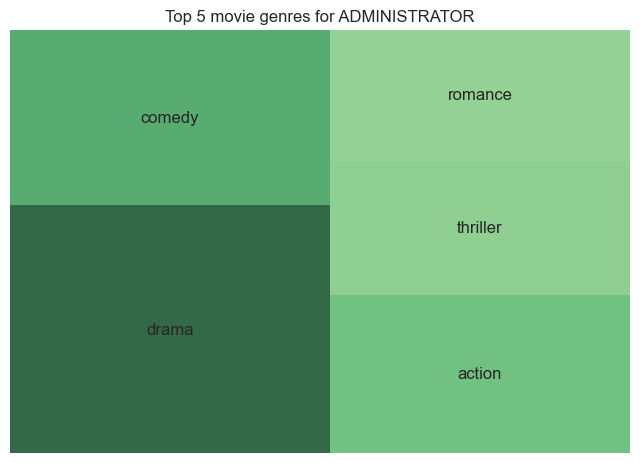

+----------+---------+
|          |   count |
|----------+---------|
| drama    |    3099 |
| comedy   |    2203 |
| action   |    1858 |
| thriller |    1570 |
| romance  |    1539 |
+----------+---------+


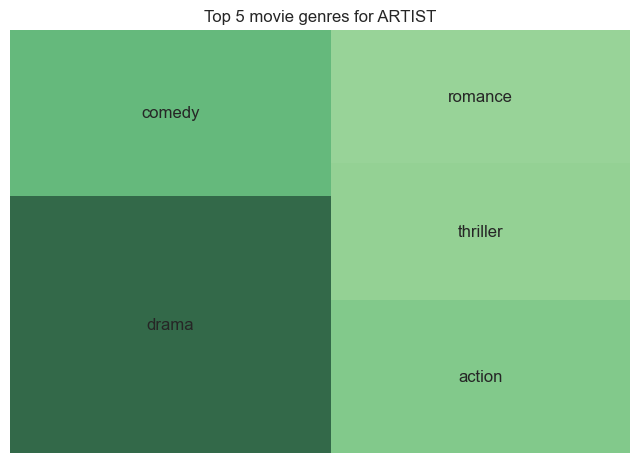

+----------+---------+
|          |   count |
|----------+---------|
| drama    |     957 |
| comedy   |     617 |
| action   |     528 |
| thriller |     476 |
| romance  |     462 |
+----------+---------+


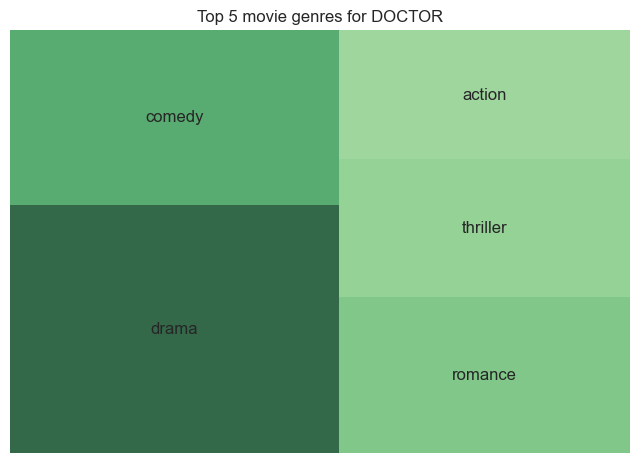

+----------+---------+
|          |   count |
|----------+---------|
| drama    |     238 |
| comedy   |     168 |
| romance  |     133 |
| thriller |     117 |
| action   |     110 |
+----------+---------+


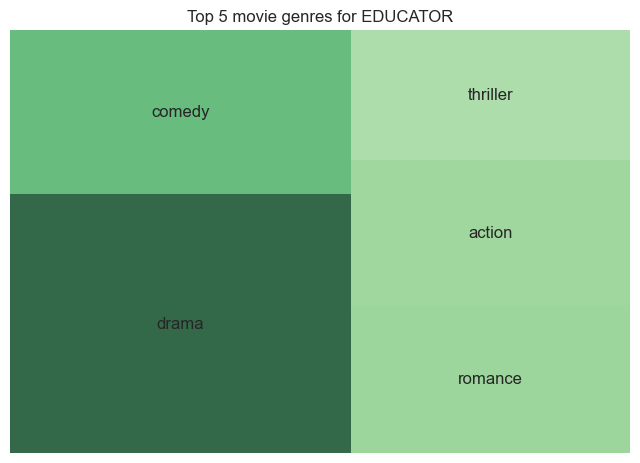

+----------+---------+
|          |   count |
|----------+---------|
| drama    |    4281 |
| comedy   |    2708 |
| romance  |    2006 |
| action   |    1962 |
| thriller |    1767 |
+----------+---------+


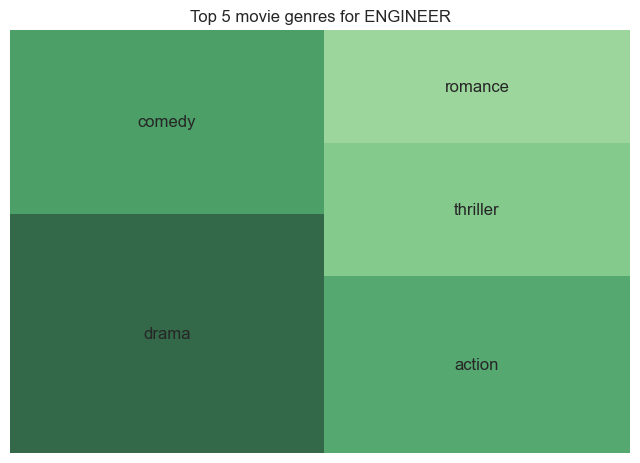

+----------+---------+
|          |   count |
|----------+---------|
| drama    |    3153 |
| comedy   |    2438 |
| action   |    2277 |
| thriller |    1712 |
| romance  |    1467 |
+----------+---------+


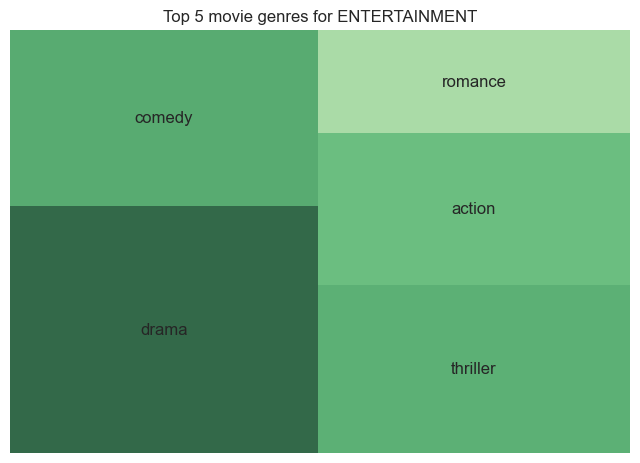

+----------+---------+
|          |   count |
|----------+---------|
| drama    |     804 |
| comedy   |     574 |
| thriller |     554 |
| action   |     499 |
| romance  |     342 |
+----------+---------+


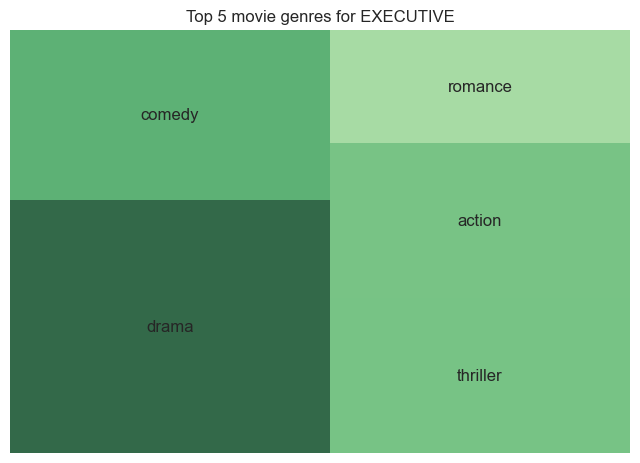

+----------+---------+
|          |   count |
|----------+---------|
| drama    |    1407 |
| comedy   |     951 |
| thriller |     811 |
| action   |     808 |
| romance  |     592 |
+----------+---------+


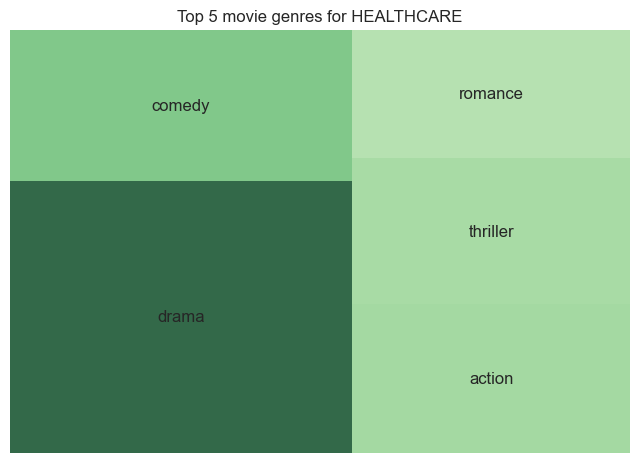

+----------+---------+
|          |   count |
|----------+---------|
| drama    |    1297 |
| comedy   |     722 |
| action   |     577 |
| thriller |     563 |
| romance  |     499 |
+----------+---------+


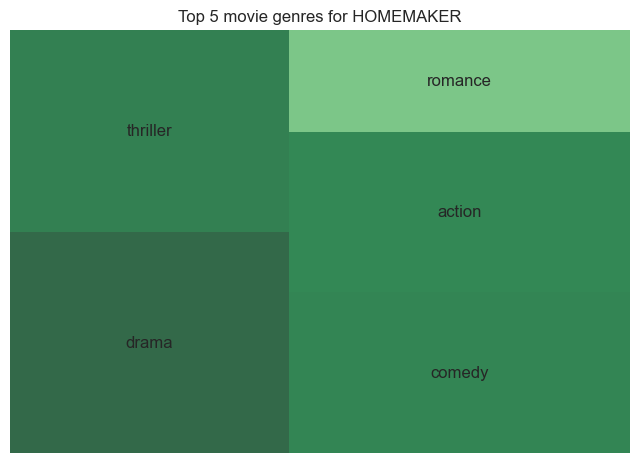

+----------+---------+
|          |   count |
|----------+---------|
| drama    |     104 |
| thriller |      95 |
| comedy   |      93 |
| action   |      92 |
| romance  |      59 |
+----------+---------+


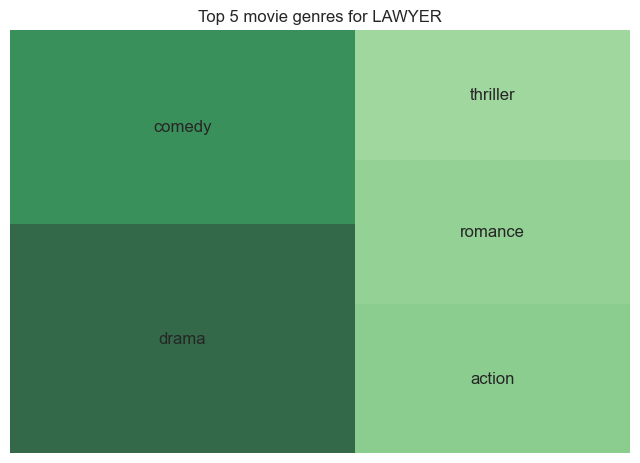

+----------+---------+
|          |   count |
|----------+---------|
| drama    |     543 |
| comedy   |     460 |
| action   |     283 |
| romance  |     272 |
| thriller |     247 |
+----------+---------+


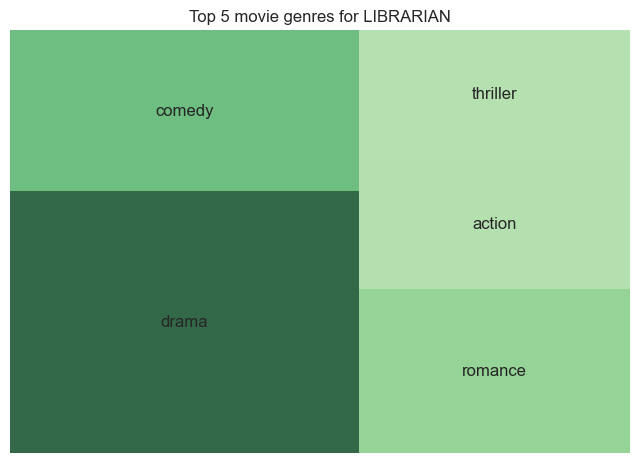

+----------+---------+
|          |   count |
|----------+---------|
| drama    |    2557 |
| comedy   |    1576 |
| romance  |    1245 |
| action   |     988 |
| thriller |     977 |
+----------+---------+


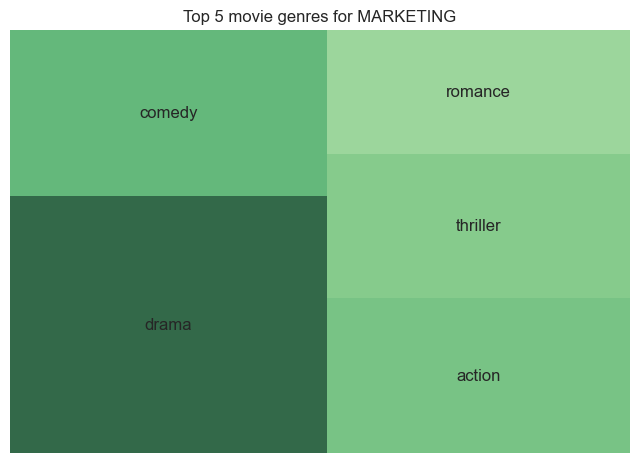

+----------+---------+
|          |   count |
|----------+---------|
| drama    |     824 |
| comedy   |     535 |
| action   |     477 |
| thriller |     442 |
| romance  |     383 |
+----------+---------+


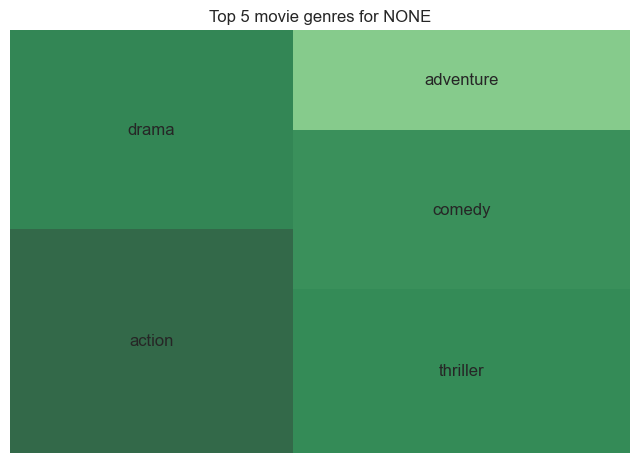

+-----------+---------+
|           |   count |
|-----------+---------|
| action    |     301 |
| drama     |     268 |
| thriller  |     262 |
| comedy    |     255 |
| adventure |     160 |
+-----------+---------+


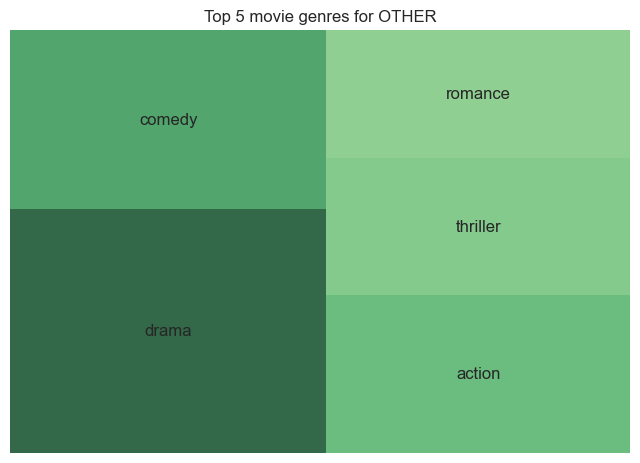

+----------+---------+
|          |   count |
|----------+---------|
| drama    |    4307 |
| comedy   |    3165 |
| action   |    2672 |
| thriller |    2321 |
| romance  |    2177 |
+----------+---------+


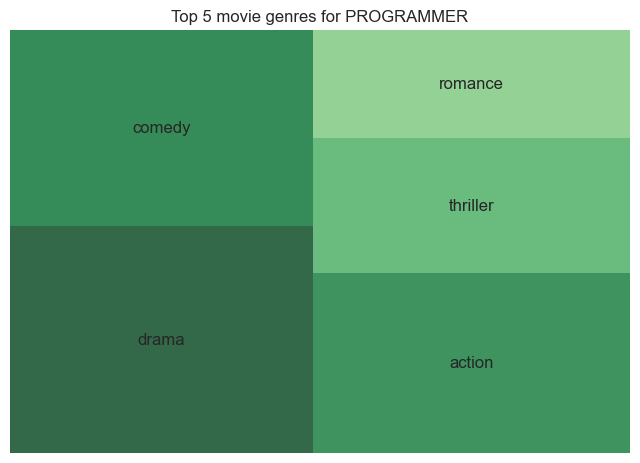

+----------+---------+
|          |   count |
|----------+---------|
| drama    |    2800 |
| comedy   |    2418 |
| action   |    2322 |
| thriller |    1750 |
| romance  |    1400 |
+----------+---------+


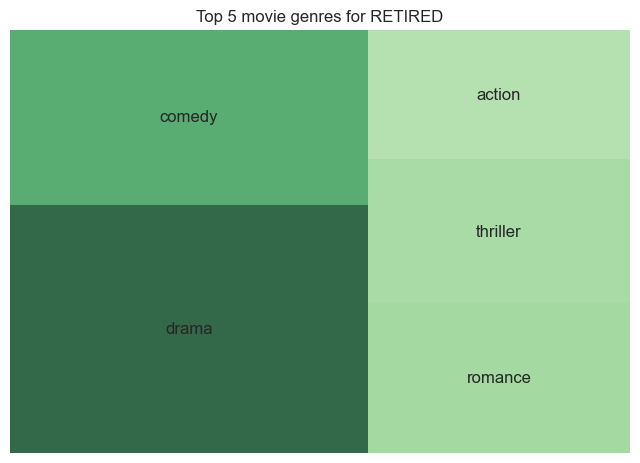

+----------+---------+
|          |   count |
|----------+---------|
| drama    |     727 |
| comedy   |     512 |
| romance  |     321 |
| thriller |     309 |
| action   |     278 |
+----------+---------+


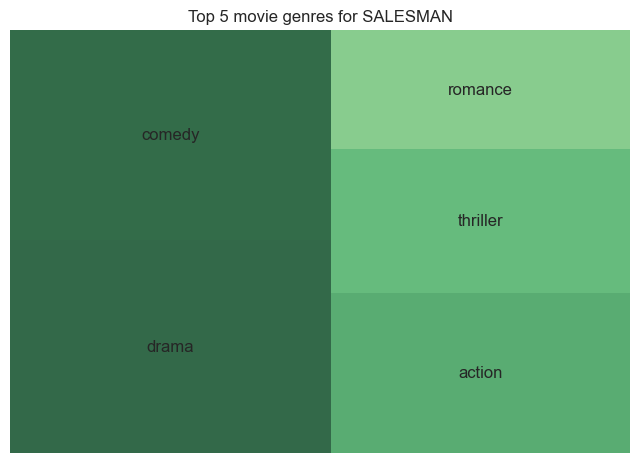

+----------+---------+
|          |   count |
|----------+---------|
| drama    |     317 |
| comedy   |     314 |
| action   |     222 |
| thriller |     200 |
| romance  |     166 |
+----------+---------+


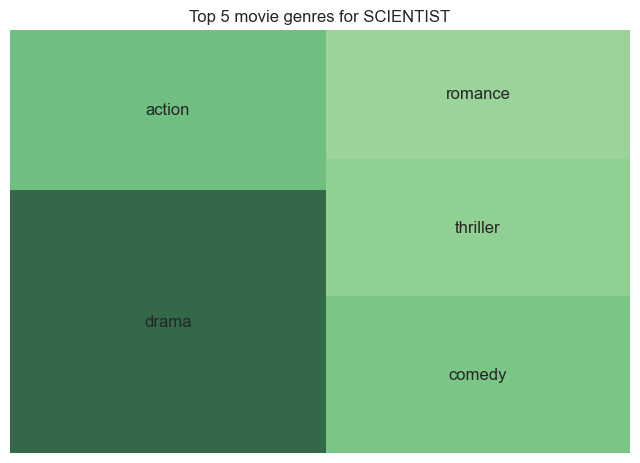

+----------+---------+
|          |   count |
|----------+---------|
| drama    |     932 |
| action   |     566 |
| comedy   |     535 |
| thriller |     469 |
| romance  |     440 |
+----------+---------+


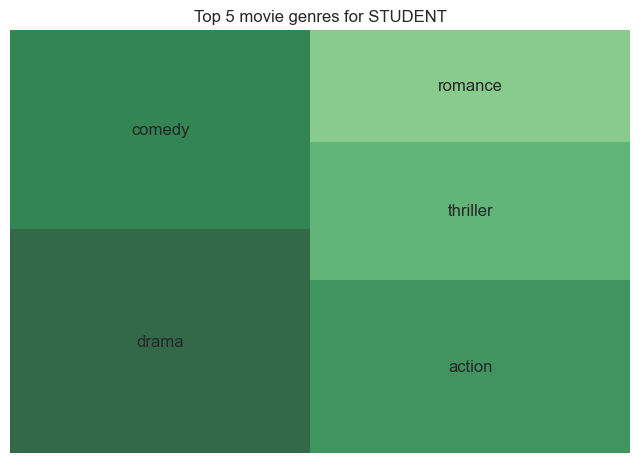

+----------+---------+
|          |   count |
|----------+---------|
| drama    |    7777 |
| comedy   |    6958 |
| action   |    6398 |
| thriller |    5130 |
| romance  |    4156 |
+----------+---------+


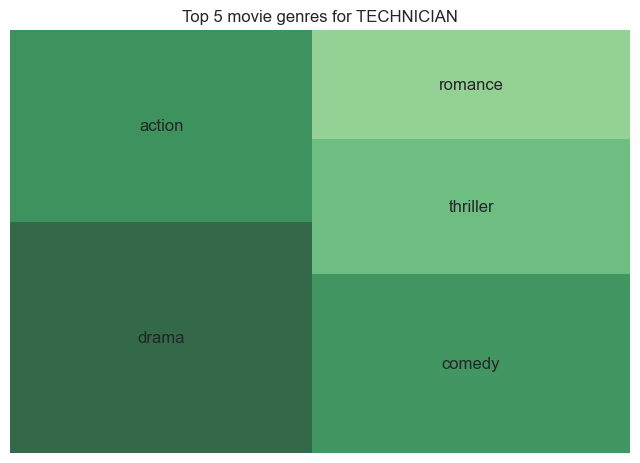

+----------+---------+
|          |   count |
|----------+---------|
| drama    |    1295 |
| action   |    1079 |
| comedy   |    1056 |
| thriller |     796 |
| romance  |     645 |
+----------+---------+


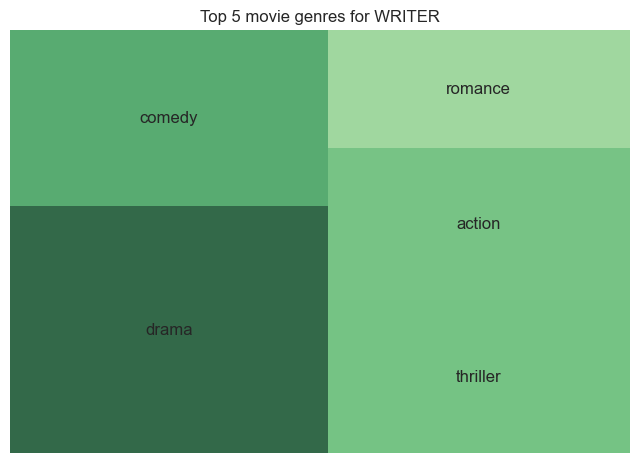

+----------+---------+
|          |   count |
|----------+---------|
| drama    |    2208 |
| comedy   |    1574 |
| thriller |    1304 |
| action   |    1292 |
| romance  |    1007 |
+----------+---------+


In [29]:
gerne_for_occupation = {}
for occ in occupations:
    genre_count = {}
    filtered_df = ratings_merged[ratings_merged.occupation == occ]
    for gen in genres:
        if filtered_df[gen].sum() > 0:
            genre_count[gen] = filtered_df[gen].sum()
    gerne_for_occupation[occ] = dict(sorted(genre_count.items(), key=lambda item: item[1], reverse=True))
for key in gerne_for_occupation.keys():
    # select colors
    cmap = plt_cm.Greens
    mini = min(gerne_for_occupation[key].values())
    maxi = max(gerne_for_occupation[key].values())
    norm = plt_colors.Normalize(vmin=mini, vmax=maxi)
    colors = [cmap(norm(value)) for value in gerne_for_occupation[key].values()]
    
    squarify.plot(
        sizes=list(gerne_for_occupation[key].values())[:5], 
        label=list(gerne_for_occupation[key].keys())[:5], 
        alpha=.8, color=colors)
    plt.title(f'Top 5 movie genres for {key.upper()}')
    plt.axis('off')
    plt.show()
    # print all tables
    df_aux = pd.DataFrame.from_dict(gerne_for_occupation[key], orient='index', columns=['count'])
    print(tabulate(df_aux[:5], headers='keys', tablefmt='psql'))

Quali sono i top 10 movies per ogni occupation?

In [30]:
movie_for_occupation = {}
for occ in occupations:
    movie_for_occupation[occ] = dict(
        ratings_merged[ratings_merged.occupation == occ].groupby(
            'movie_title').count()['user_id'].sort_values(ascending=False)[:10])
for occ in occupations:
    df_aux = pd.DataFrame({"title": movie_for_occupation.get(occ).keys()}, 
                          index=range(0, len(movie_for_occupation.get(occ).keys())))

In [31]:
movie_for_occupation

{'administrator': {'English Patient, The': 47,
  'Star Wars': 44,
  'Return of the Jedi': 40,
  'Air Force One': 38,
  'Jerry Maguire': 38,
  'Contact': 38,
  'Liar Liar': 37,
  'Fargo': 36,
  'Silence of the Lambs, The': 34,
  'Independence Day (ID4)': 33},
 'artist': {'Star Wars': 18,
  'Chasing Amy': 17,
  'Liar Liar': 16,
  'Return of the Jedi': 16,
  'Contact': 15,
  'Fargo': 14,
  'Raiders of the Lost Ark': 13,
  'Fugitive, The': 13,
  'English Patient, The': 13,
  'Godfather, The': 12},
 'doctor': {'Titanic': 5,
  'English Patient, The': 5,
  'Air Force One': 5,
  'Toy Story': 4,
  'Ransom': 4,
  "Ulee's Gold": 4,
  'L.A. Confidential': 4,
  'Fargo': 4,
  'Eat Drink Man Woman': 3,
  'Twister': 3},
 'educator': {'English Patient, The': 61,
  'Fargo': 54,
  'Star Wars': 50,
  'Contact': 45,
  'Godfather, The': 43,
  'Full Monty, The': 42,
  'Toy Story': 41,
  'Return of the Jedi': 41,
  'Sense and Sensibility': 41,
  'Jerry Maguire': 40},
 'engineer': {'Star Wars': 50,
  'Toy Stor

Quali sono i top 10 movies per ogni fascia d'età?

In [32]:
df_interval_age = ratings_merged.copy()
df_interval_age.age.max()

73

In [33]:
min_20 = df_interval_age[df_interval_age.age <= 20]['user_id'].count()
between_21_30 = df_interval_age[(df_interval_age.age > 20) & (df_interval_age.age <= 30)]['user_id'].count()
between_31_45 = df_interval_age[(df_interval_age.age > 30) & (df_interval_age.age <= 45)]['user_id'].count()
more_45 = df_interval_age[df_interval_age.age > 45]['user_id'].count()
print(min_20, between_21_30, between_31_45, more_45)

12311 39204 30988 17488


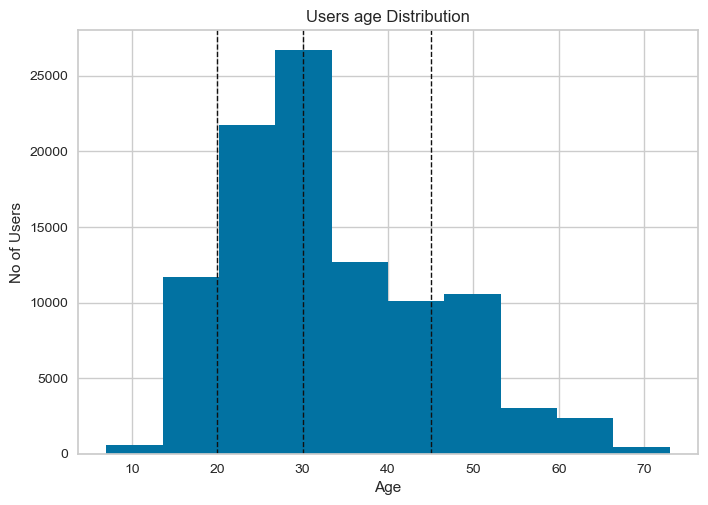

In [34]:
# 12313, 39208, 30991, 17488
plt.hist(data=df_interval_age, x='age')
plt.axvline(20, color='k', linestyle='dashed', linewidth=1)
plt.axvline(30, color='k', linestyle='dashed', linewidth=1)
plt.axvline(45, color='k', linestyle='dashed', linewidth=1)
plt.xlabel('Age')
plt.ylabel('No of Users')
plt.title('Users age Distribution')
plt.show()

In [35]:
# age attribute from int to category 
df_interval_age.age = pd.cut(
    df_interval_age.age, bins=(0, 20, 30, 45, 75), 
    labels=["Less than 20", "Between 21 and 30", "Between 31 and 45", "More than 45"]
)

In [36]:
less_than_20 = df_interval_age[df_interval_age.age == 'Less than 20']
between_21_30 = df_interval_age[df_interval_age.age == 'Between 21 and 30']
between_31_45 = df_interval_age[df_interval_age.age == 'Between 31 and 45']
more_than_45 = df_interval_age[df_interval_age.age == 'More than 45']

In [37]:
top_ten_by_age = {}
top_ten_by_age['Less than 20'] = less_than_20.groupby('movie_title').count().sort_values(
    by='user_id', ascending=False)[:10].index.to_list()
top_ten_by_age['Between 21 and 30'] = between_21_30.groupby('movie_title').count().sort_values(
    by='user_id', ascending=False)[:10].index.to_list()
top_ten_by_age['Between 31 and 45'] = between_31_45.groupby('movie_title').count().sort_values(
    by='user_id', ascending=False)[:10].index.to_list()
top_ten_by_age['More than 45'] = more_than_45.groupby('movie_title').count().sort_values(
    by='user_id', ascending=False)[:10].index.to_list()

In [38]:
for label in ["Less than 20", "Between 21 and 30", "Between 31 and 45", "More than 45"]:
    print(top_ten_by_age[label])

['Scream', 'Contact', 'Star Wars', 'Return of the Jedi', 'Liar Liar', 'Independence Day (ID4)', 'Toy Story', 'Chasing Amy', 'Twelve Monkeys', 'Rock, The']
['Star Wars', 'Scream', 'Return of the Jedi', 'Contact', 'Fargo', 'Liar Liar', 'Toy Story', 'Chasing Amy', 'Twelve Monkeys', 'Rock, The']
['Star Wars', 'Return of the Jedi', 'English Patient, The', 'Fargo', 'Contact', 'Liar Liar', 'Silence of the Lambs, The', 'Godfather, The', 'Raiders of the Lost Ark', 'Toy Story']
['English Patient, The', 'Fargo', 'Star Wars', 'Air Force One', 'Godfather, The', 'Contact', 'Full Monty, The', 'Titanic', 'Liar Liar', 'Return of the Jedi']


Quali sono i top 10 movies per ogni genere cinematografico?

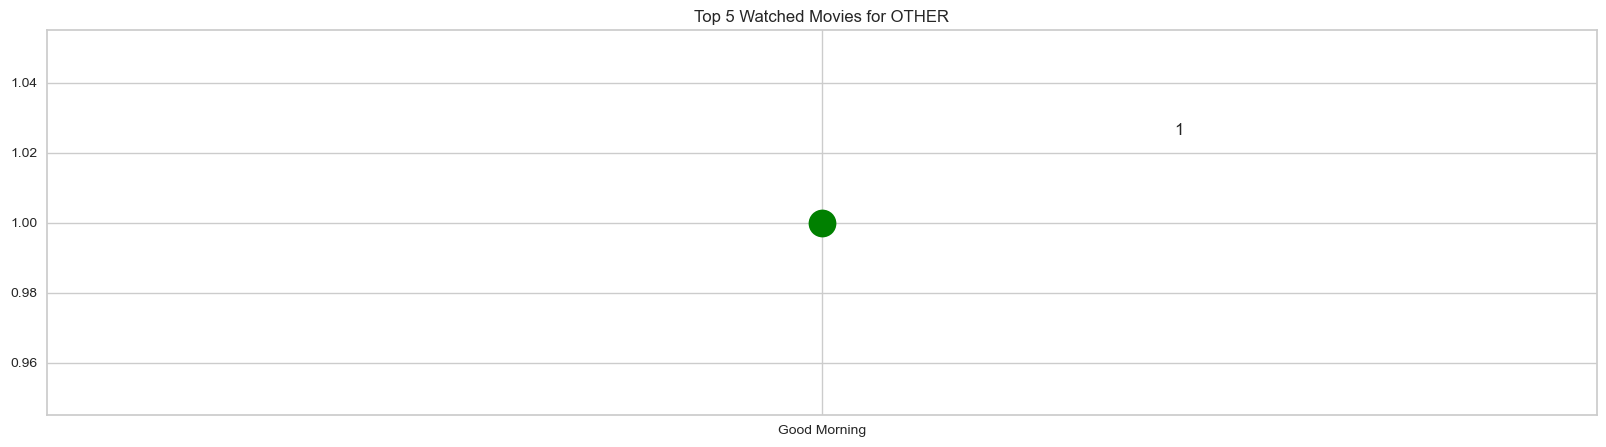

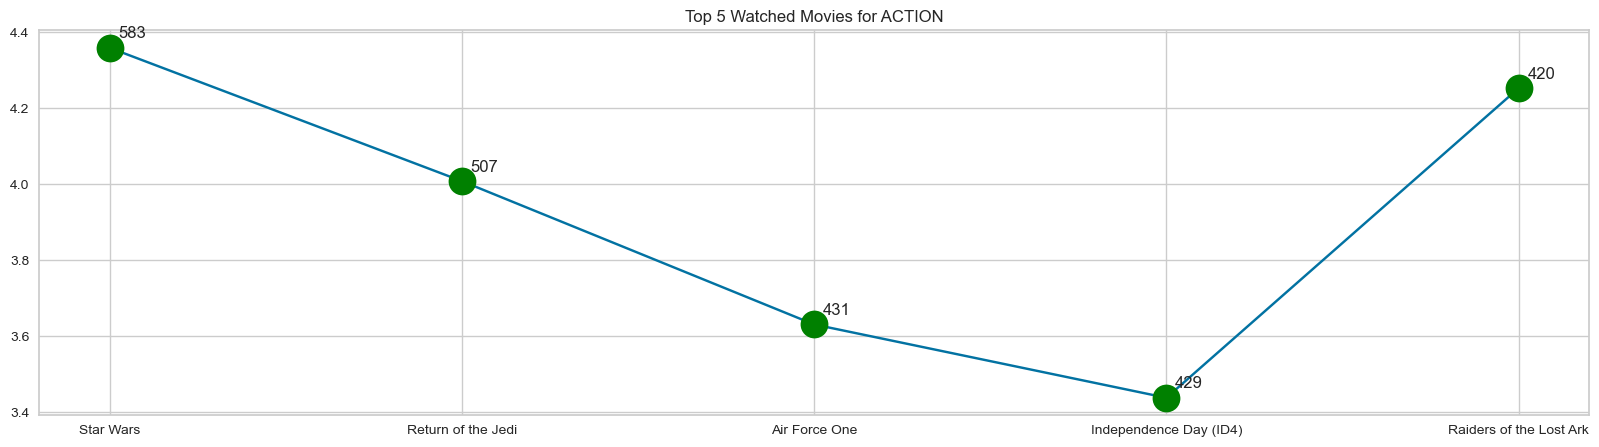

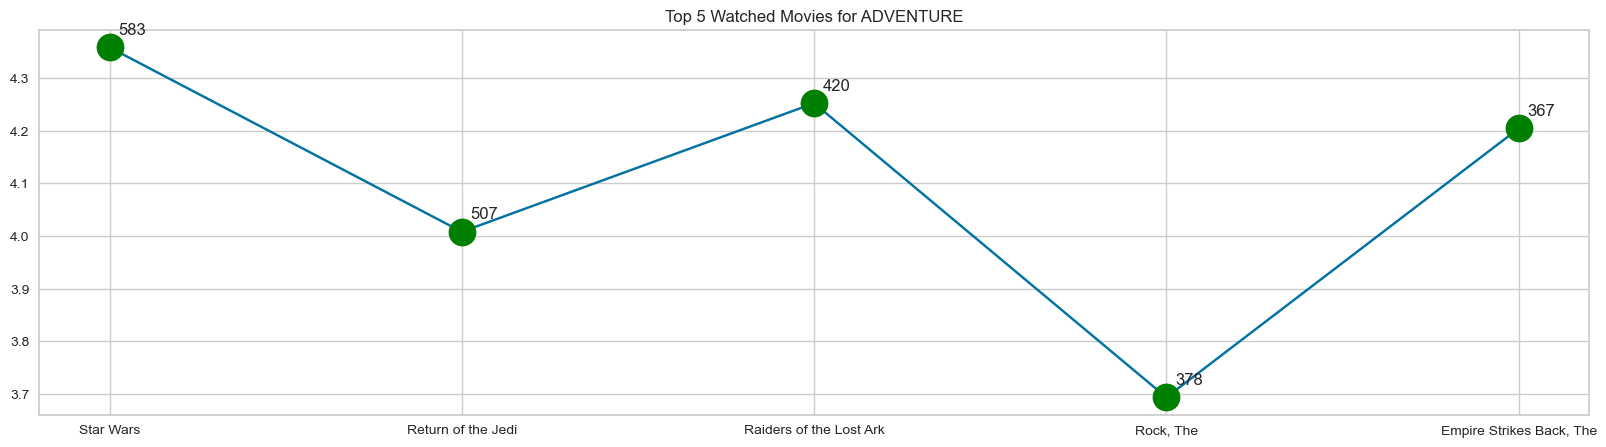

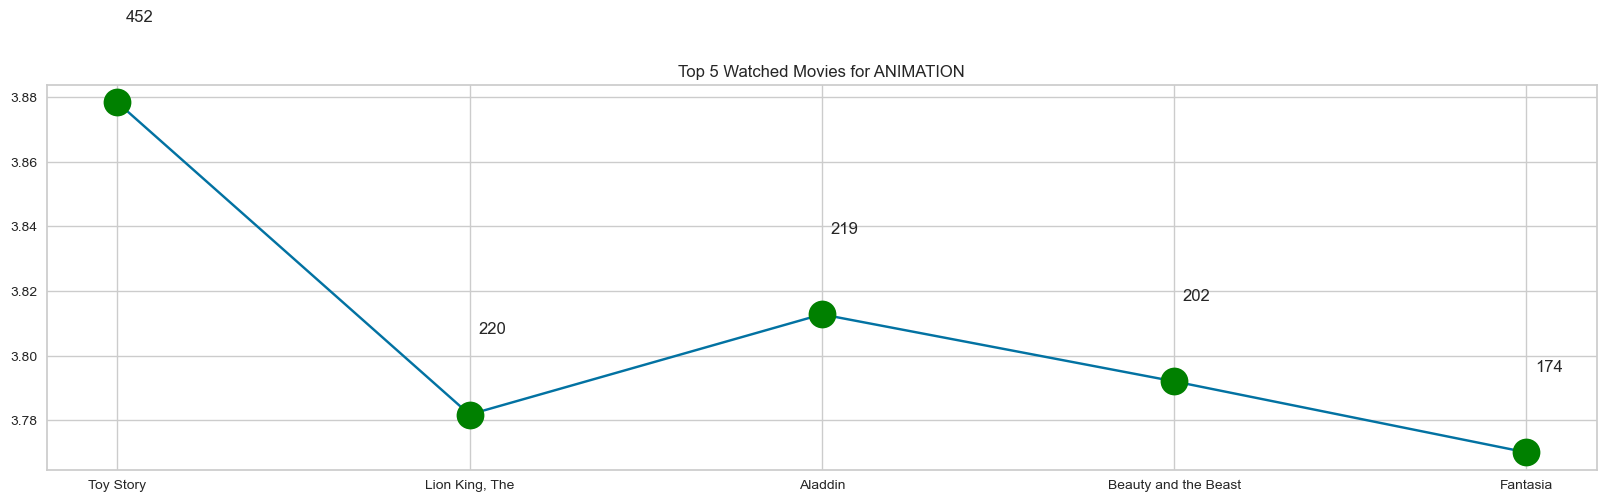

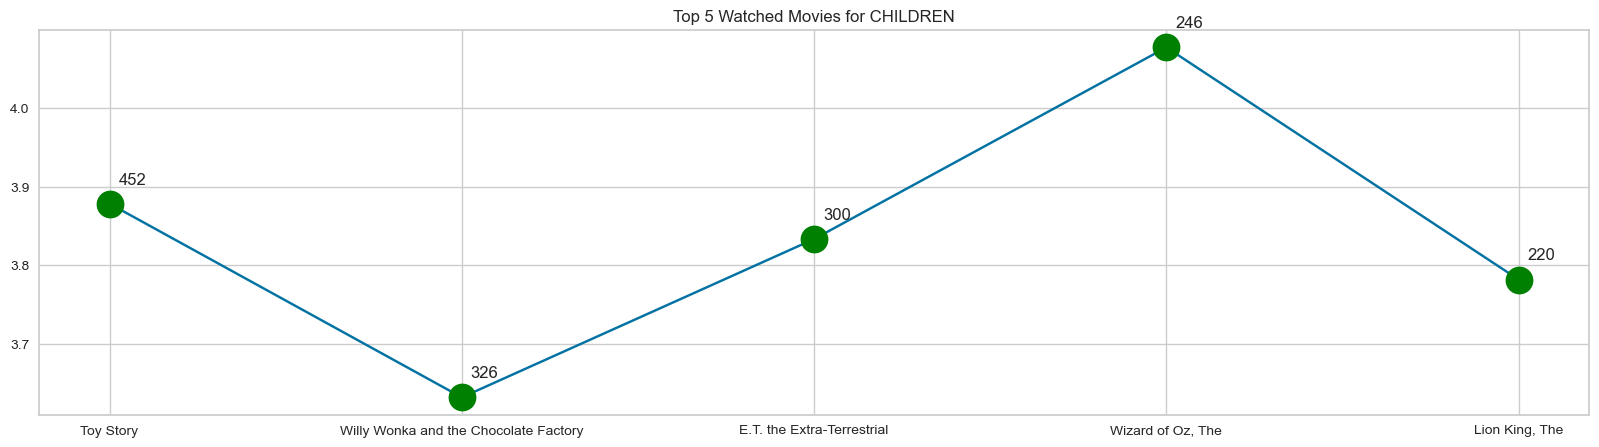

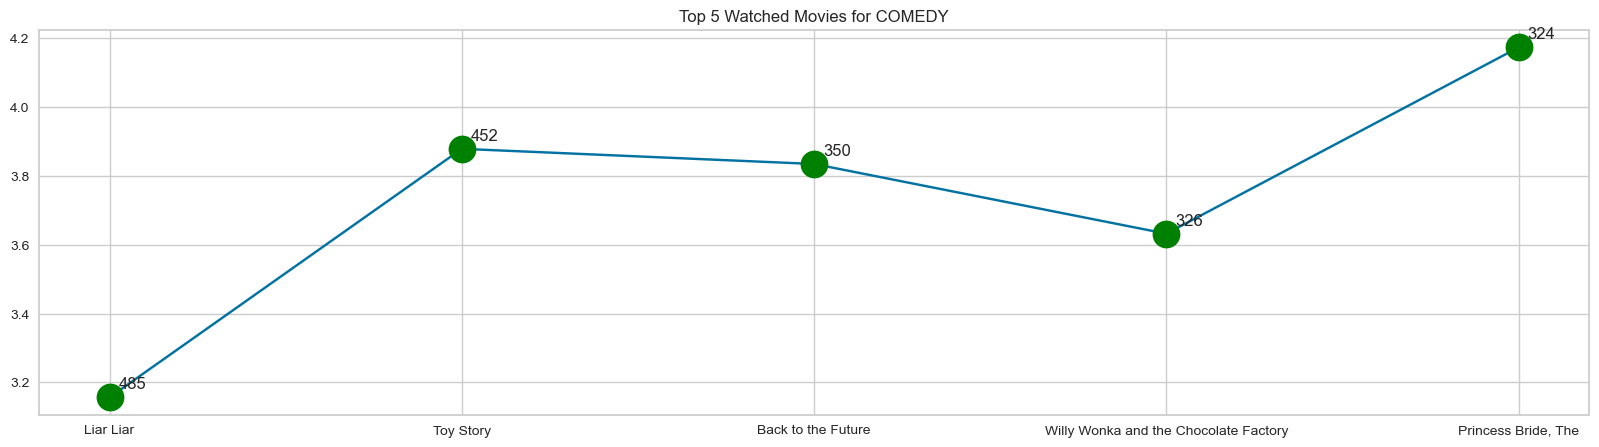

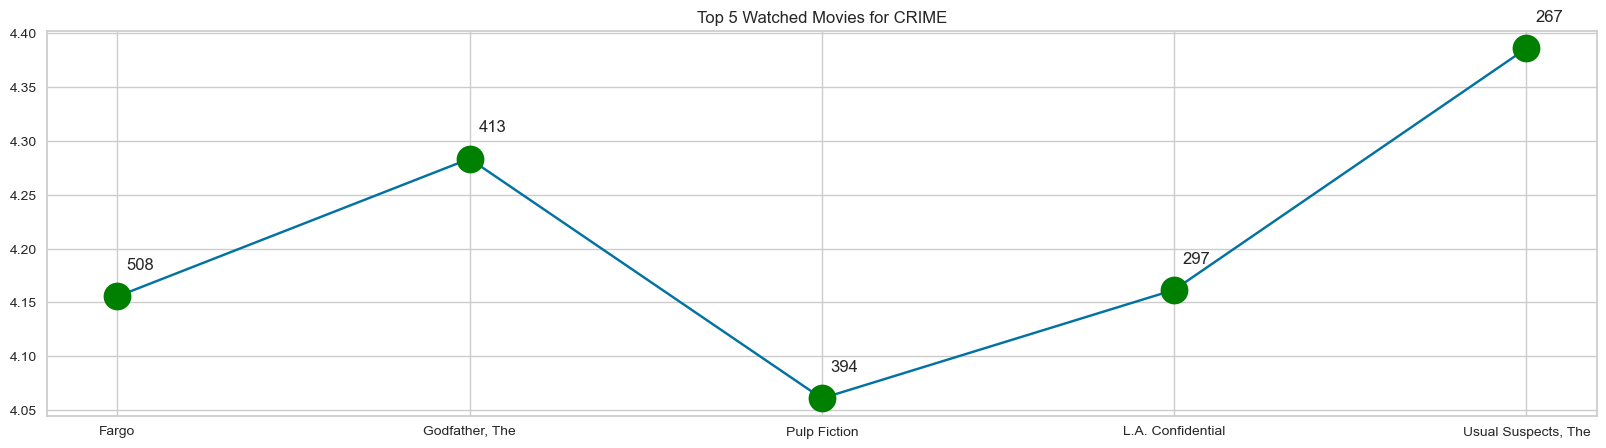

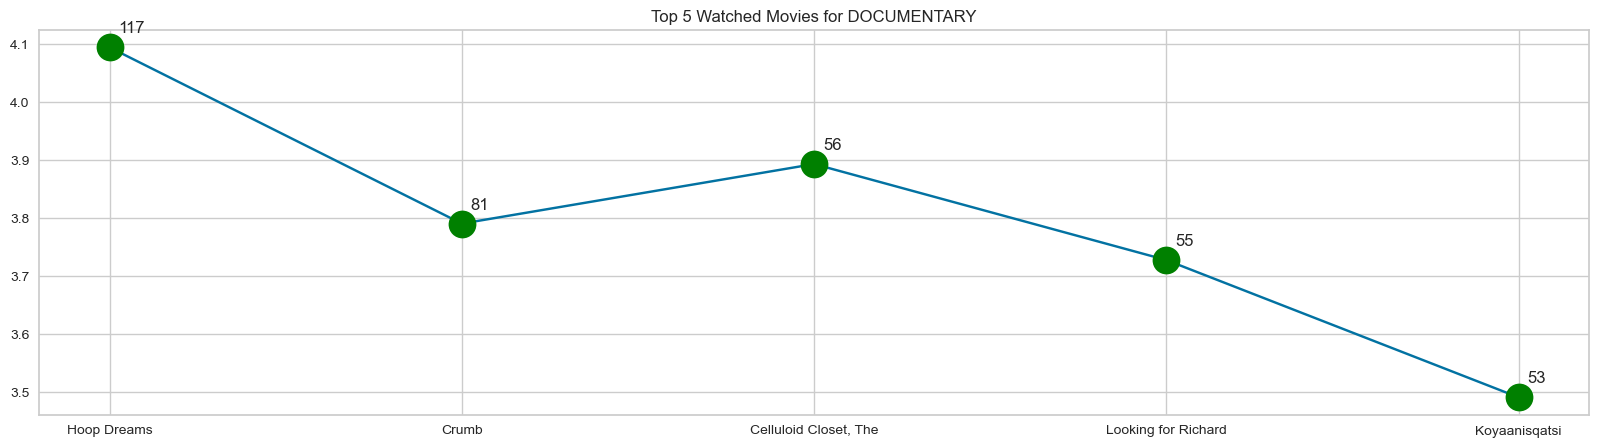

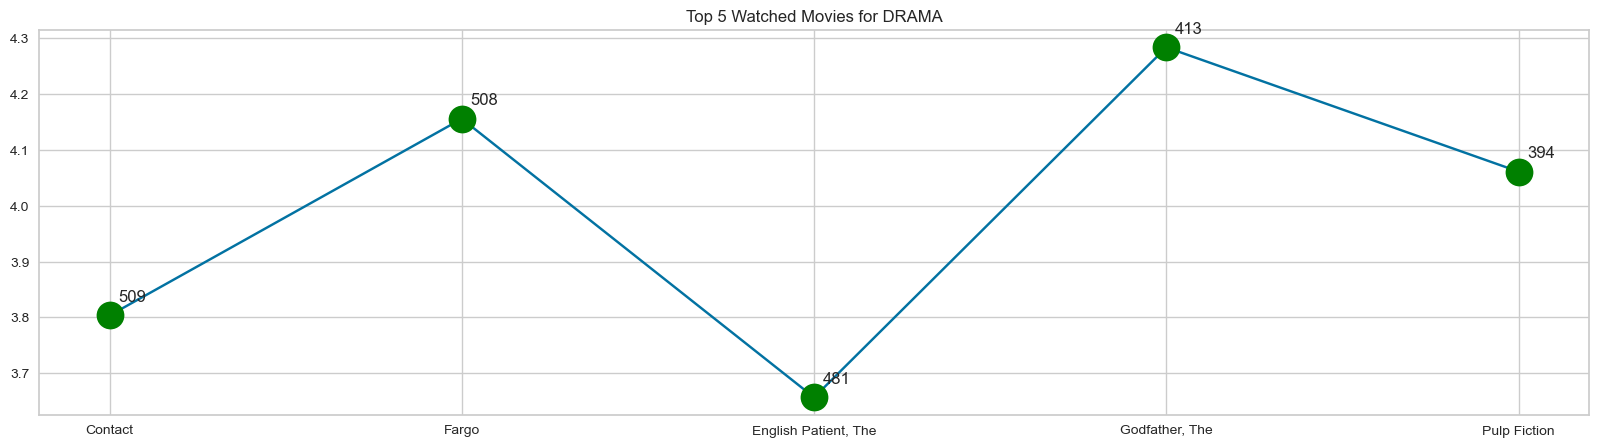

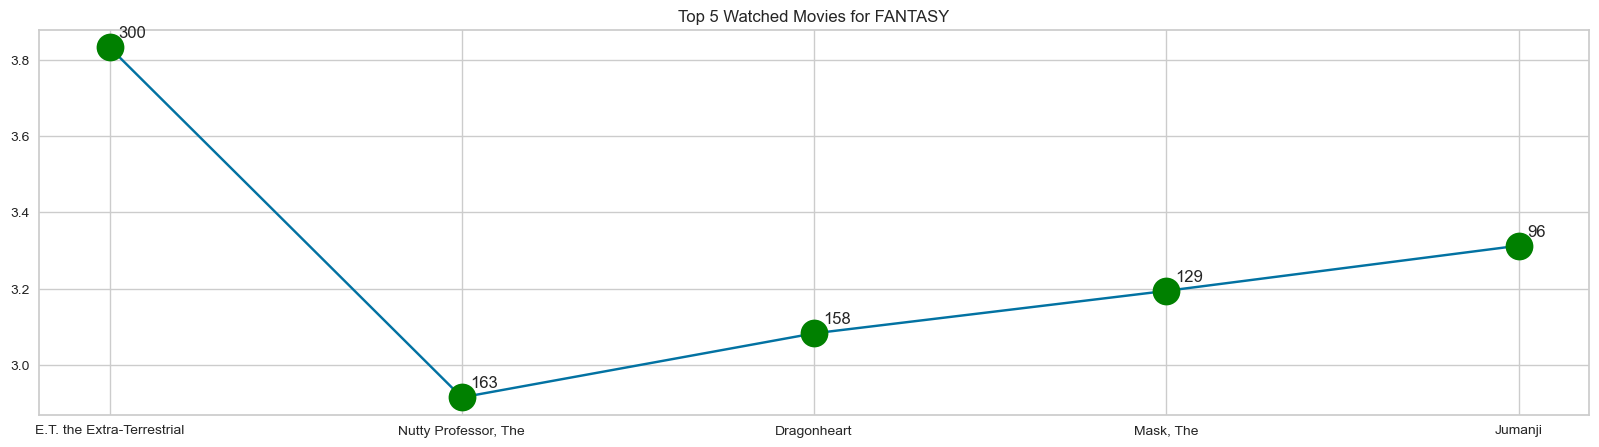

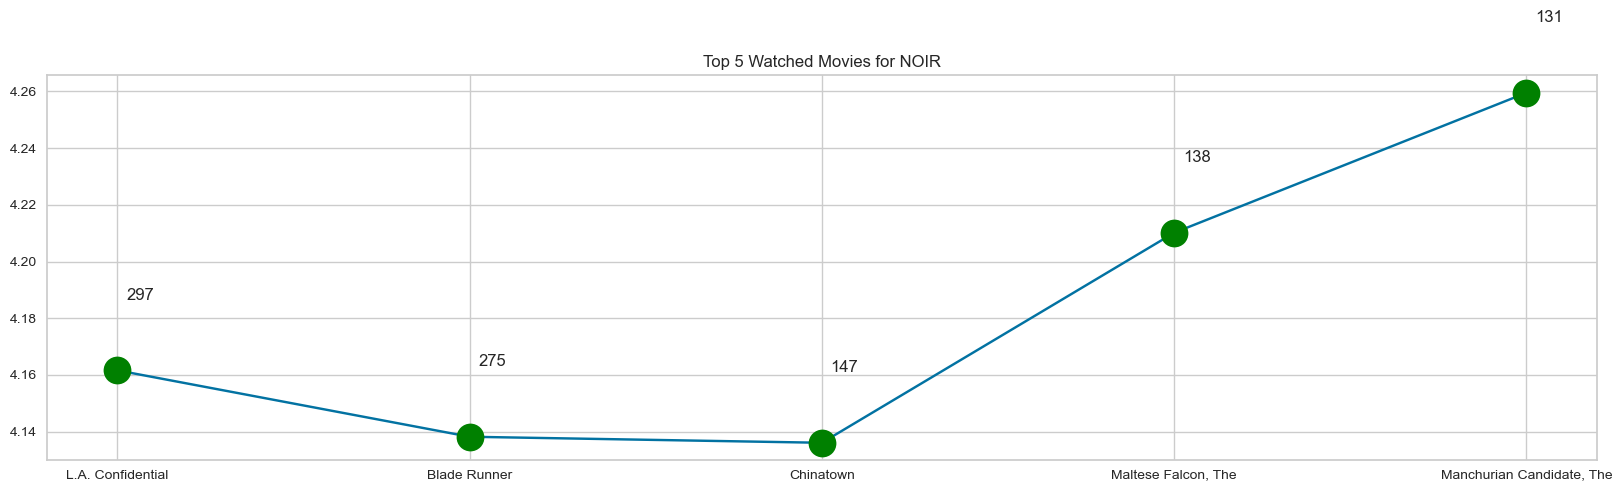

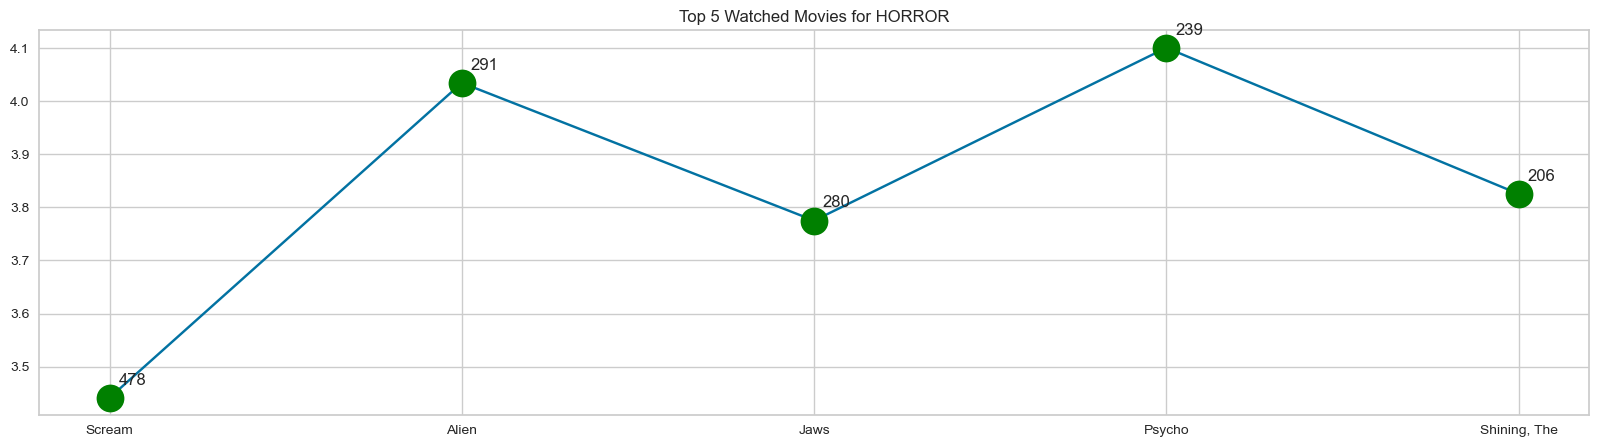

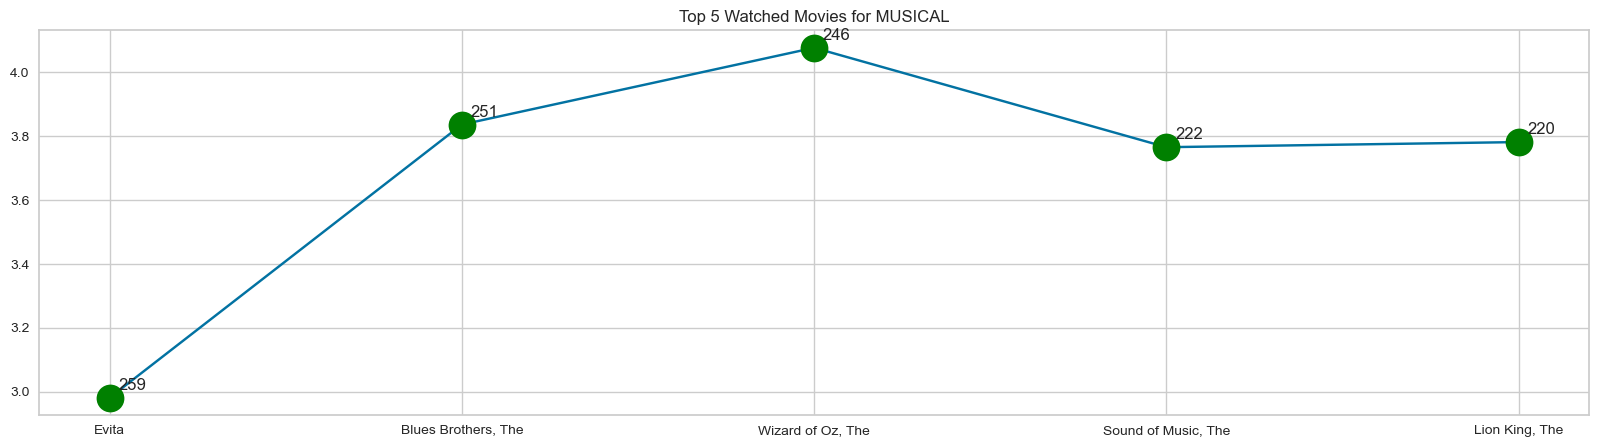

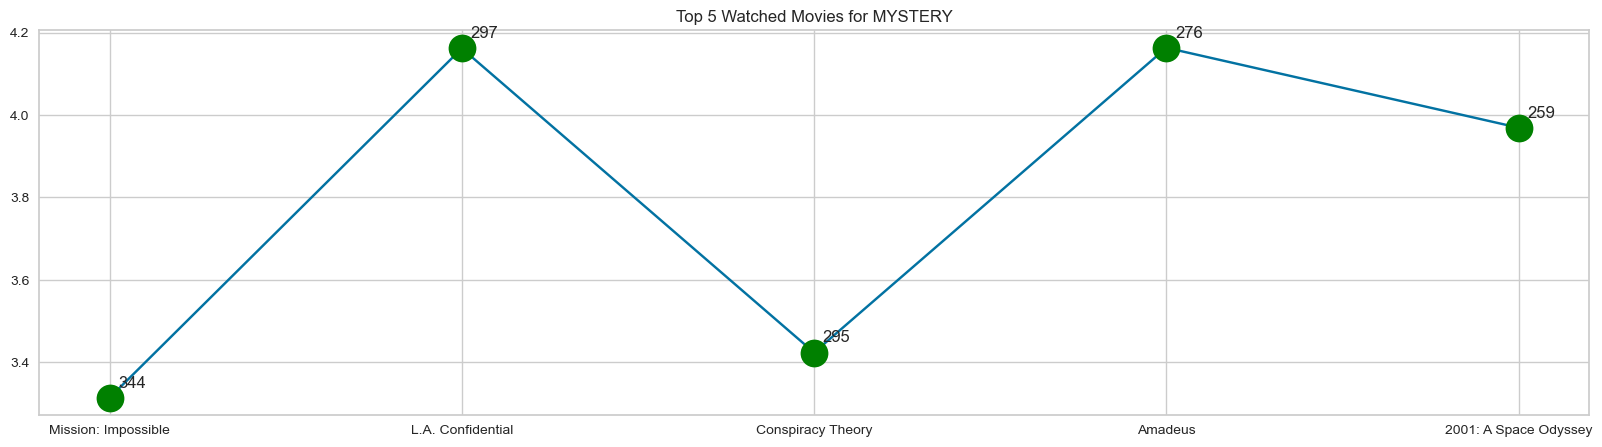

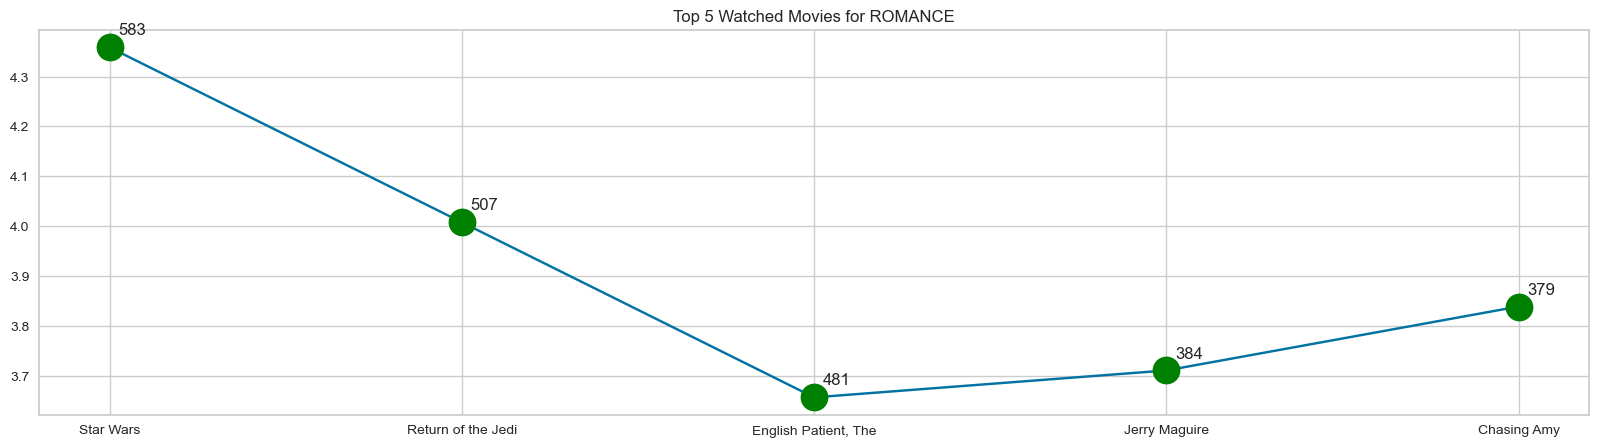

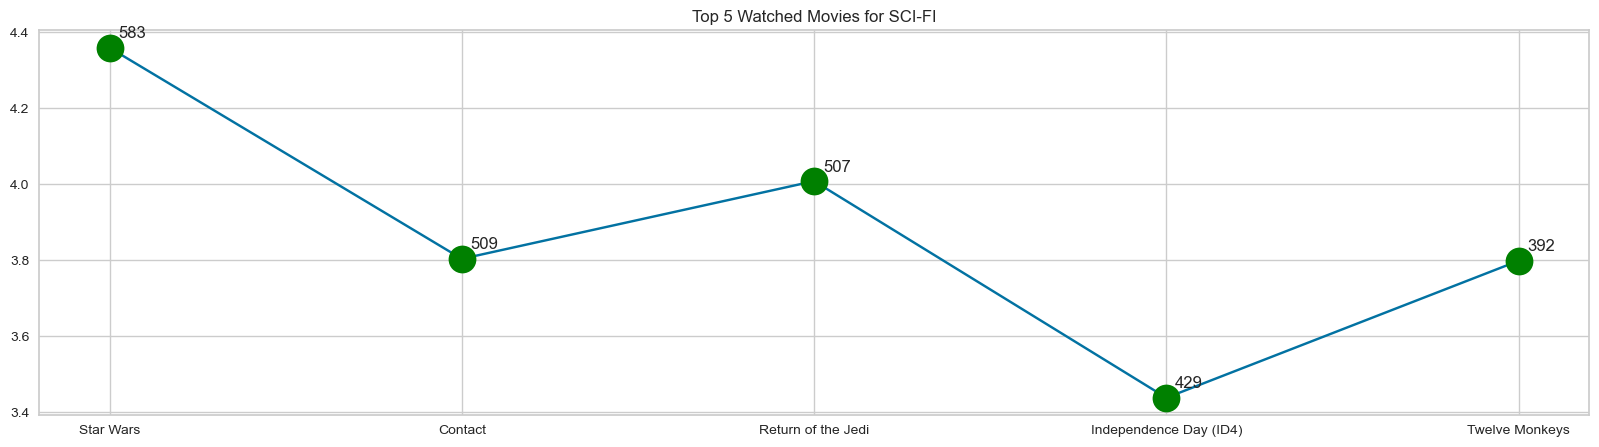

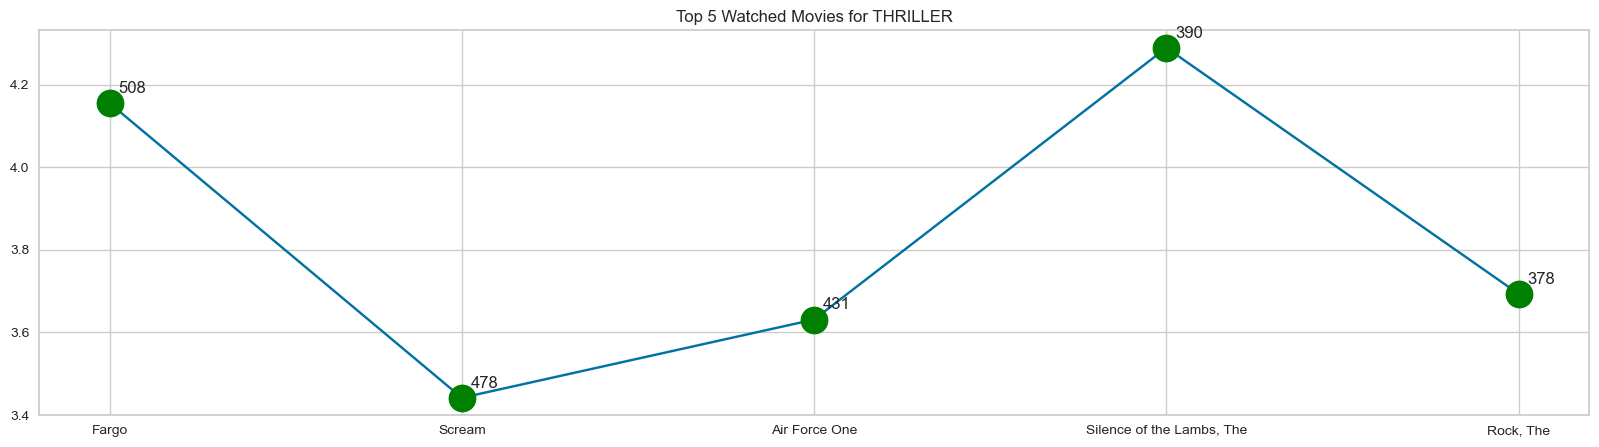

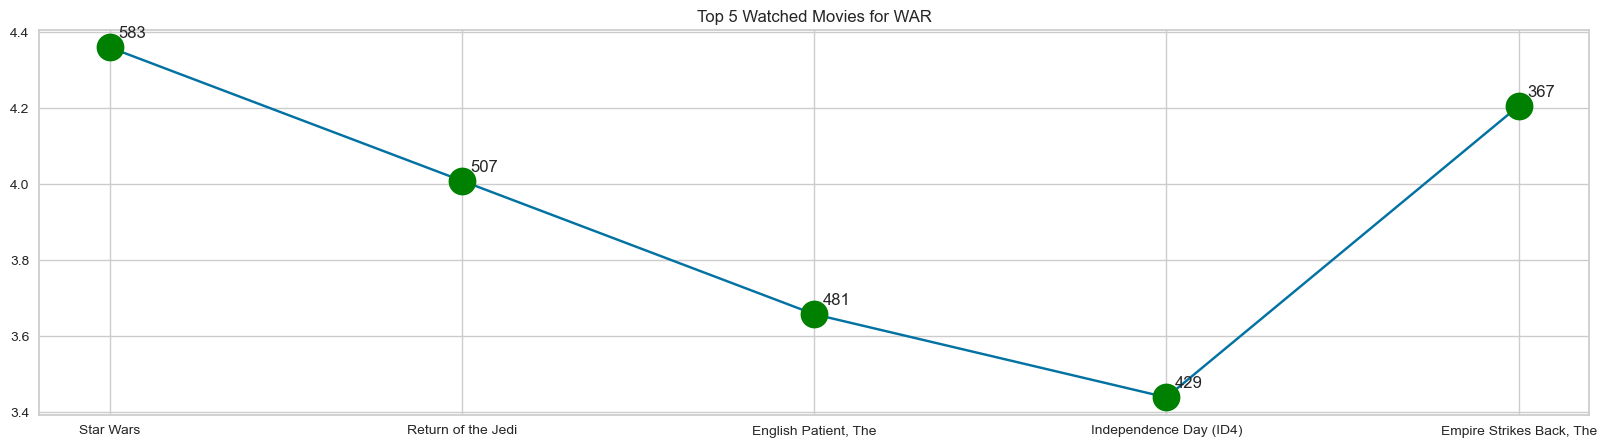

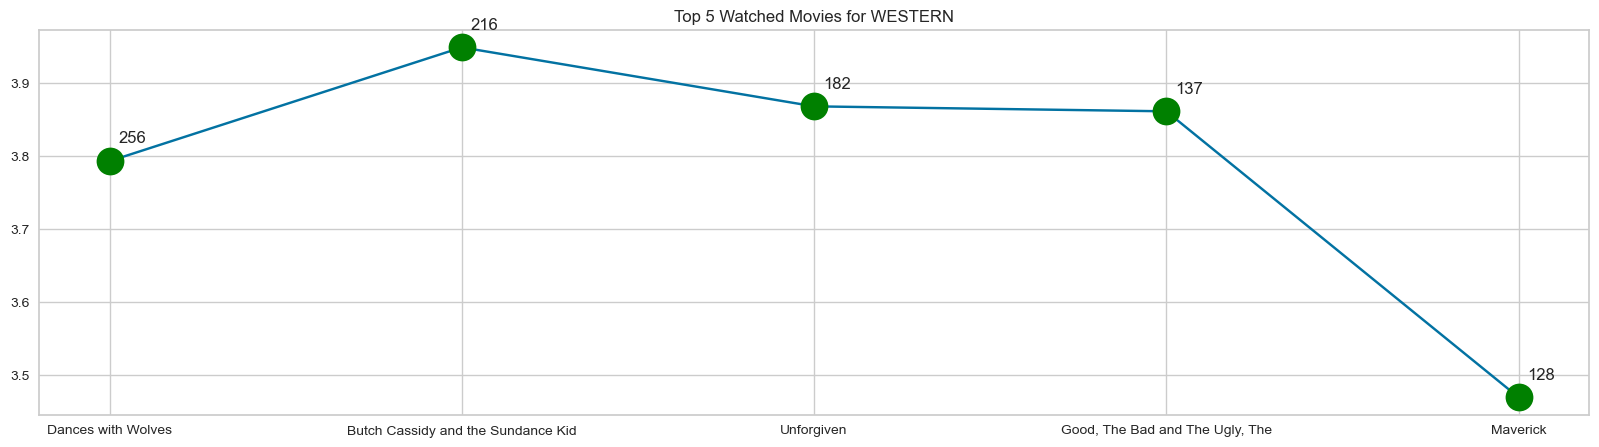

In [39]:
for genre in genres:
    dict_aux = {}
    movie_titles = []
    ratings_list = []
    series_aux = ratings_merged[ratings_merged[genre]==1].groupby('movie_title')['user_id'].count().sort_values(ascending=False)[:5]
    for movie_title in series_aux.index:
        movie_titles.append(movie_title)
        ratings_list.append(ratings_merged[ratings_merged['movie_title']==movie_title]['rating'].mean())
    dict_aux['movies'] = movie_titles
    dict_aux['ratings'] = ratings_list
    dict_aux['times_watched'] = series_aux.values
    df_aux = pd.DataFrame(dict_aux)
    x = df_aux['movies']
    y = df_aux['ratings']
    tickvalues = range(0, len(df_aux.movies))
    plt.figure(figsize=(20, 5))
    plt.xticks(ticks=tickvalues, labels=df_aux.movies, rotation='horizontal')
    plt.title(f'Top 5 Watched Movies for {genre.upper()}')
    plt.plot(x,y)
    for i in range(0, len(df_aux)):
        plt.plot(df_aux.index[i], df_aux.ratings[i], marker='o', markersize=20, 
                 markeredgecolor="red", markerfacecolor="green")
        plt.annotate(df_aux.times_watched[i], (df_aux.index[i], df_aux.ratings[i]),
                    xytext=(df_aux.index[i]+0.025, df_aux.ratings[i]+0.025))
    plt.show()

<a id='4'></a>
___

## Filling della matrice di Rating
[Indice](#0)

In [40]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['user_id', 'movie_id', 'rating']], reader)
random_state = 10
kf = KFold(n_splits=5, random_state=random_state)

#### Algoritmo di Classificazione K-NN con Cosine Similarity
default --> user_based=True

In [41]:
knn_cosine = KNNBasic(verbose=True, sim_options={'name': 'cosine'})

best_rmse = np.inf
for trainset, testset in kf.split(data):

    k = knn_cosine.fit(trainset)
    predictions = knn_cosine.test(testset)

    rmse = accuracy.rmse(predictions, verbose=True)
    
    if rmse < best_rmse:
        train_cosine = trainset
        test_cosine = testset

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0238
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0188
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0241
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0071
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0097


In [42]:
cosine_ks = []
cosine_rmses = []
lowest_rmse = np.inf
for k in range(0, 100, 10):
    knn_cosine = KNNBasic(k=k, verbose=True, sim_options={'name': 'cosine'})
    
    model = knn_cosine.fit(train_cosine)
    predictions = knn_cosine.test(test_cosine) 
    rmse = accuracy.rmse(predictions, verbose=True)
    
    cosine_rmses.append(rmse)
    cosine_ks.append(model.k)
    
    if rmse < lowest_rmse:
        lowest_rmse = rmse
        best_k = model.k

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.1259
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0389
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0170
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0115
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0097
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0098
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0100
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0105
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0109
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0110


In [43]:
mat_knn_cosine = ratings.pivot_table(index=['user_id'], columns=['movie_id'], values='rating')
mat_knn_cosine.fillna(0, inplace=True)
sparsity = 1.0 - np.count_nonzero(mat_knn_cosine) / mat_knn_cosine.size

In [44]:
# best model
model_cosine = KNNBasic(k=best_k, verbose=True, sim_options={'name': 'cosine'})
model_cosine.fit(train_cosine)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [45]:
print('This is going to take a bit of time!')
for i in range(1, 944): # users
    for j in range(1, 1683): # movies
        if mat_knn_cosine.loc[i, j] == 0:
            mat_knn_cosine.loc[i, j] = np.round(knn_cosine.predict(uid=i, iid=j).est)

This is going to take a bit of time!


In [46]:
try:
    mat_knn_cosine.to_csv('/Users/saraarizzi/jupyter/progetto/final_data/mat_knn_cosine.csv')
except Exception:
    pass

#### Algoritmo di Classificazione K-NN con Pearson Correlation

In [47]:
knn_pearson = KNNBasic(verbose=True, sim_options={'name': 'pearson'})

best_rmse = np.inf
for trainset, testset in kf.split(data):

    knn_pearson.fit(trainset)
    predictions = knn_pearson.test(testset)

    rmse = accuracy.rmse(predictions, verbose=True)
    
    if rmse < best_rmse:
        train_pearson = trainset
        test_pearson = testset
        best_rmse = rmse

Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0166
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0116
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0166
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0041
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0052


In [48]:
pearson_ks = []
pearson_rmses = []

lowest_rmse = np.inf
for k in range(0, 100, 10):
    knn_pearson = KNNBasic(k=k, verbose=True, sim_options={'name': 'pearson'})
    
    model = knn_pearson.fit(train_pearson)
    predictions = knn_pearson.test(test_pearson)
    
    rmse = accuracy.rmse(predictions, verbose=True)
    pearson_rmses.append(rmse)
    pearson_ks.append(model.k)
    
    if rmse < lowest_rmse:
        lowest_rmse = rmse
        best_k = model.k

Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.1178
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0294
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0112
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0061
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0041
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0039
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0035
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0032
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0032
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 1.0032


In [49]:
# best model
model_pearson = KNNBasic(k=best_k, verbose=True, sim_options={'name': 'pearson'})
model_pearson.fit(train_pearson)

Computing the pearson similarity matrix...
Done computing similarity matrix.


In [50]:
mat_knn_pearson = ratings.pivot_table(index=['user_id'], columns=['movie_id'], values='rating')
mat_knn_pearson.fillna(0, inplace=True)

In [51]:
print('This is going to take a bit of time!')
for i in range(1, 944): # users
    for j in range(1, 1683): # movies
        if mat_knn_pearson.loc[i, j] == 0:
            mat_knn_pearson.loc[i, j] = np.round(knn_pearson.predict(uid=i, iid=j).est)

This is going to take a bit of time!


In [52]:
try:
    mat_knn_pearson.to_csv('/Users/saraarizzi/jupyter/progetto/final_data/mat_knn_pearson.csv')
except Exception:
    pass

**Confronto cosine e pearson**

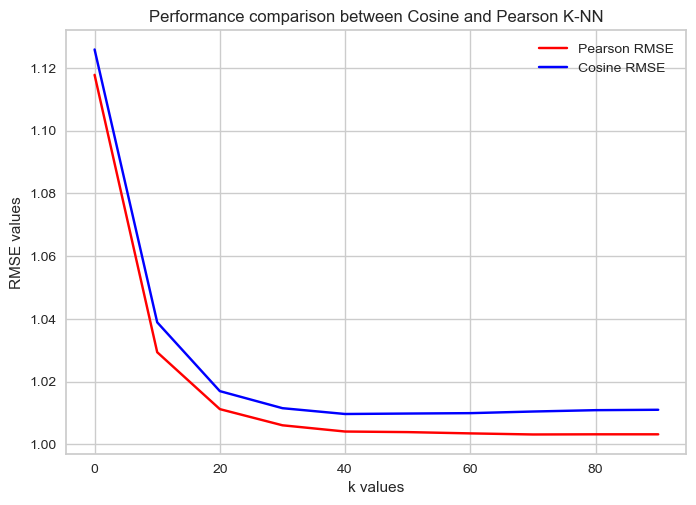

In [53]:
plt.figure()
plt.plot(range(0, 100, 10), pearson_rmses, color='red', label='Pearson RMSE')
plt.plot(range(0, 100, 10), cosine_rmses, color='blue', label='Cosine RMSE')
plt.title('Performance comparison between Cosine and Pearson K-NN')
plt.xlabel('k values')
plt.ylabel('RMSE values')
plt.legend()
plt.show()

#### Algoritmo di Classificazione SVD 

In [54]:
svd = SVD()

best_rmse = np.inf
for trainset, testset in kf.split(data):

    svd.fit(trainset)
    predictions = svd.test(testset)

    rmse = accuracy.rmse(predictions, verbose=True)
    
    if rmse < best_rmse:
        train_svd = trainset
        test_svd = testset
        best_rmse = rmse

RMSE: 0.9431
RMSE: 0.9364
RMSE: 0.9406
RMSE: 0.9351
RMSE: 0.9270


In [55]:
# todo try to optimize n factor and n epochs
svd_factor = []
svd_rmses = []

lowest_rmse = np.inf
for k in range(0, 100, 10):
    svd = SVD(n_factors=k, n_epochs=20)
    
    model = svd.fit(train_svd)
    predictions = svd.test(test_svd)
    
    rmse = accuracy.rmse(predictions, verbose=True)
    svd_rmses.append(rmse)
    
    if rmse < lowest_rmse:
        lowest_rmse = rmse
        best_factor = k

RMSE: 0.9335
RMSE: 0.9294
RMSE: 0.9267
RMSE: 0.9276
RMSE: 0.9274
RMSE: 0.9261
RMSE: 0.9275
RMSE: 0.9250
RMSE: 0.9281
RMSE: 0.9261


In [56]:
svd = SVD(n_factors=best_factor, n_epochs=20)
svd.fit(train_svd)
mat_svd = ratings.pivot_table(index=['user_id'], columns=['movie_id'], values='rating')
mat_svd.fillna(0, inplace=True)

In [57]:
print('This is going to take a bit of time!')
for i in range(1, len(mat_svd.index)+1): # users
    for j in range(1, len(mat_svd.columns)+1): # movies
        if mat_svd.loc[i, j] == 0:
            mat_svd.loc[i, j] = np.round(svd.predict(uid=i, iid=j).est)

This is going to take a bit of time!


In [58]:
try:
    mat_svd.to_csv('/Users/saraarizzi/jupyter/progetto/final_data/mat_svd.csv')
except Exception:
    pass

<a id='5'></a>
___

## Confronto Performance
[Indice](#0)

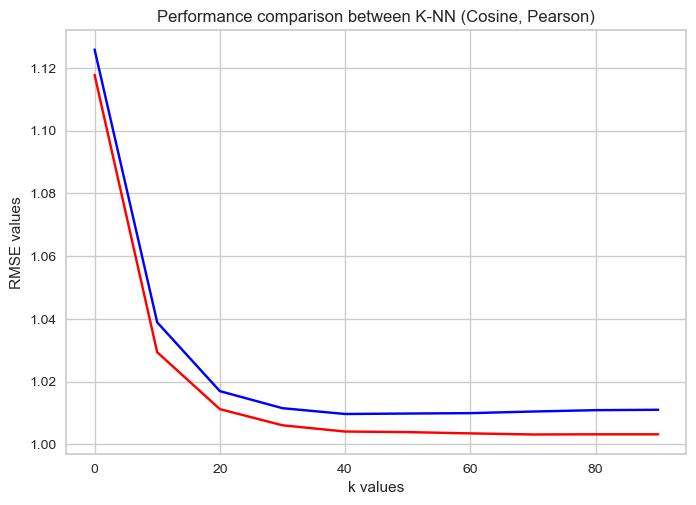

In [59]:
plt.figure()
plt.plot(range(0, 100, 10), pearson_rmses, color='red', label='Pearson RMSE')
plt.plot(range(0, 100, 10), cosine_rmses, color='blue', label='Cosine RMSE')
plt.title('Performance comparison between K-NN (Cosine, Pearson)')
plt.xlabel('k values')
plt.ylabel('RMSE values')
plt.show()

In [60]:
min_cosine = np.array(cosine_rmses).min()
min_pearson = np.array(pearson_rmses).min()
min_svd = np.array(svd_rmses).min()
final = [min_cosine, min_pearson, min_svd]

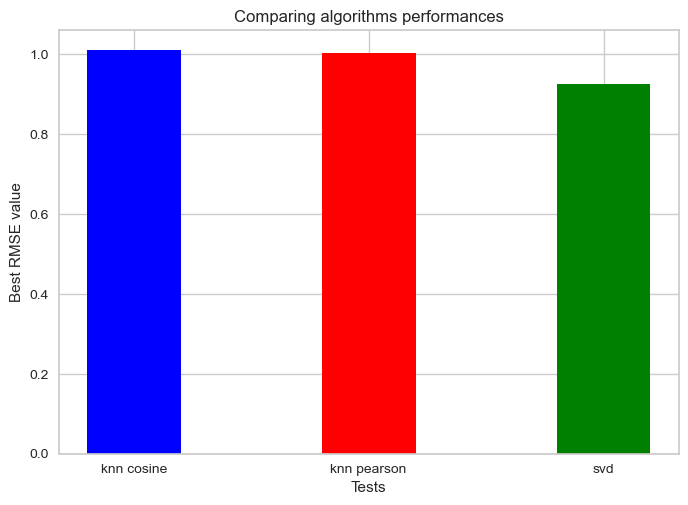

In [61]:
label = ['knn cosine', 'knn pearson', 'svd']
 
# plotting a bar chart
plt.bar(range(1, 4, 1), final, tick_label=label, width=0.4, color=['blue', 'red', 'green'])

plt.xlabel('Tests')
plt.ylabel('Best RMSE value')
plt.title('Comparing algorithms performances')
 
plt.show()

<a id='6'></a>
___

## Rappresentazione matrice di rating (sparsa)
[Indice](#0)

In [62]:
def plot_matrix(nodes, mat, **kwargs):
    edge = kwargs.get('edge', 0.5)
    unique_node = np.unique(list(itertools.chain.from_iterable(nodes)))
    
    G = nx.Graph()

    G.add_nodes_from(unique_node)

    for tup in nodes:
        G.add_edge(tup[0], tup[1], weight=mat[tup[0]-1][tup[1]-1])

    elarge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] >= edge]

    pos = nx.spring_layout(G, seed=7)

    n = nx.draw_networkx_nodes(G, pos, node_size=1)
    n.set_color('black')
    n.set_facecolor('black')

    # draw edges
    nx.draw_networkx_edges(G, pos, width=.2, edgelist=elarge, edge_color='red', alpha=1)

    ax = plt.gca()
    ax.margins(0.02)
    plt.axis("off")
    plt.tight_layout()

    plt.show()

In [63]:
rat_mat = ratings.pivot_table(index=['user_id'], columns=['movie_id'], values='rating')
rat_mat.fillna(0, inplace=True)

In [64]:
pairwise_mat = pairwise_distances(rat_mat, metric='cosine', n_jobs=-1)
dist_mat = 1 - pairwise_mat

### Plot con tutta la matrice delle distanze

Plotto l'arco con cosine similarity maggiore di 0.5

In [65]:
nodes = []
try:
    with open('/Users/saraarizzi/jupyter/progetto/saved_data/nodes.csv', newline='\n') as f:
        reader = csv.reader(f)
        nodes = list(reader)
        nodes = [[int(s) for s in sublist] for sublist in nodes] 
except Exception as e:
    print(f'Exception occurred: {e}')
    print('This is going to take a looooot of time!')
    for i in range(0, len(dist_mat)):
        for j in range(i, len(dist_mat)):
            if [i+1, j+1] not in nodes and [j+1, i+1] not in nodes and i+1 != j+1:
                nodes.append([i+1, j+1])

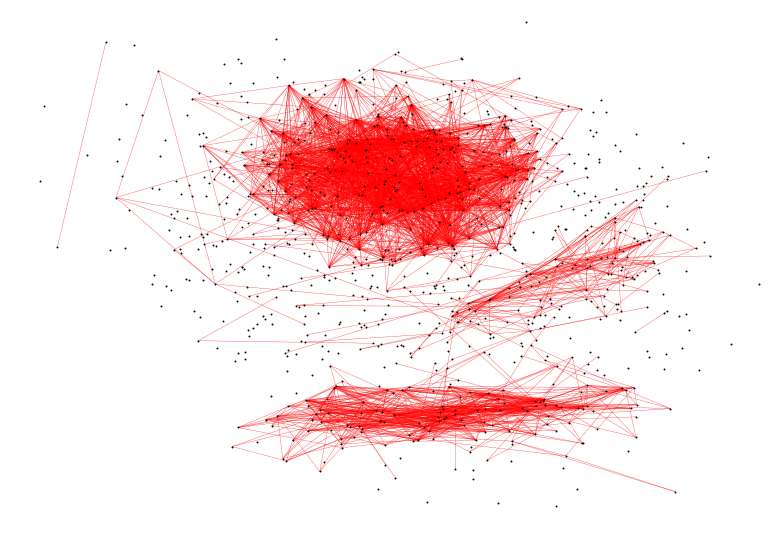

In [66]:
plot_matrix(nodes, dist_mat)

### Plot parziali
Plotto solo i nodi che tra loro hanno cosine similarity maggiore di una certa soglia e disegno gli archi con cosine maggiore

In [67]:
def get_nodes(x, mat):
    nodes = []
    for i in range(0, len(mat)):
        for j in range(i, len(mat)):
            if mat[i][j] > x and [i+1, j+1] not in nodes and [j+1, i+1] not in nodes and i+1 != j+1:
                nodes.append([i+1, j+1])
    return nodes

### Esempio
Nel report presento più casi ma visto il tempo d'esecuzione non indifferente, qui riporto un esempio in cui utilizzo solo i nodi che abbiano tra loro cosine similarity maggiore di 0.5.

Nella funzione posso specificare gli archi da disegnare, di base è 0.5 (quindi in questo esempio tutti i nodi sono collegati). Negli esempi riportati nel report ho utilizzato diversi criteri per rappresentare diversi livelli di similarity.

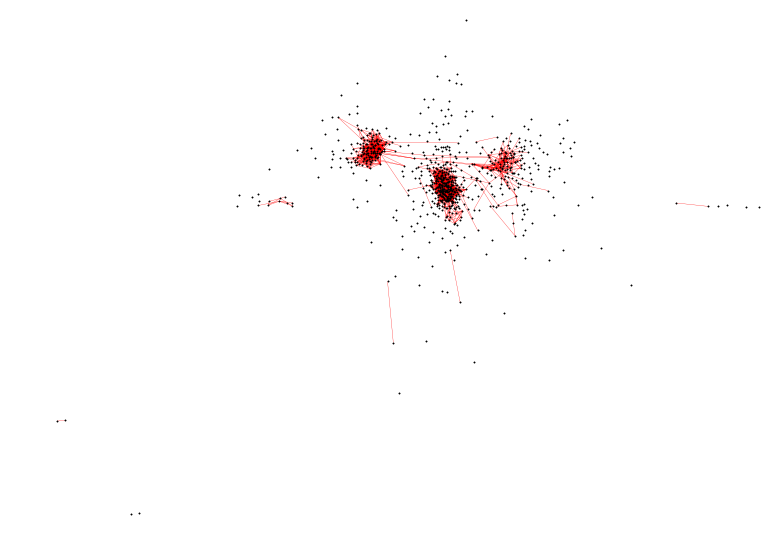

In [68]:
plot_matrix(get_nodes(0.4, dist_mat), dist_mat)

___

## Rappresentazione matrice di rating (riempita)
[Indice](#0)

In [69]:
try:
    rat_mat = pd.read_csv('/Users/saraarizzi/jupyter/progetto/final_data/mat_knn_pearson.csv', 
                          header=0, index_col=0)
except:
    rat_mat = ratings.pivot_table(index=['user_id'], columns=['movie_id'], values='rating')
    rat_mat.fillna(0, inplace=True)

In [70]:
pairwise_mat = pairwise_distances(rat_mat, metric='cosine', n_jobs=-1)
dist_mat = 1 - pairwise_mat

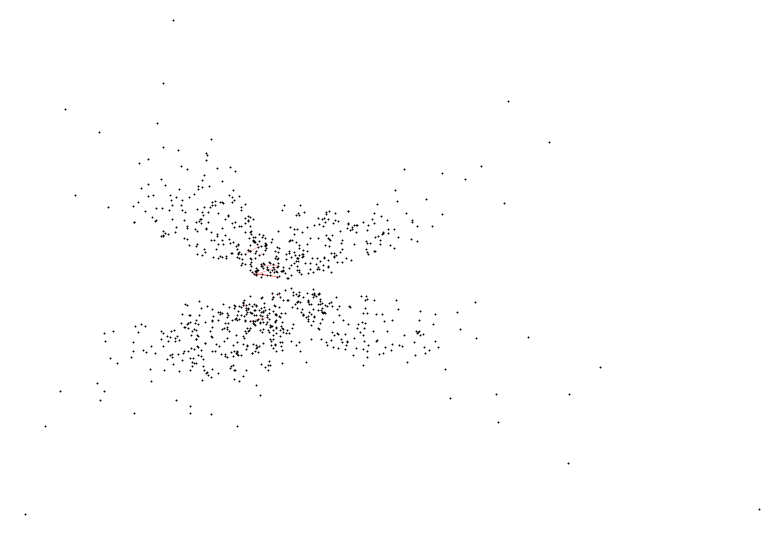

In [71]:
plot_matrix(get_nodes(0.97, dist_mat), dist_mat, edge=0.9875)

<a id='7'></a>
___

## K-Means clustering
[Indice](#0)

Utilizzo la matrice riempita utilizzando l'algoritmo di Matrix Factorization perchè riporta i risultati migliori in termini di RMSE e MAE.

In [72]:
try:
    rm = pd.read_csv('/Users/saraarizzi/jupyter/progetto/final_data/mat_knn_pearson.csv', header=0, index_col=0)
except:
    rm = mat_svd # mat_knn_cosine, mat_knn_pearson

Stimo il numero ottimale di clusters

### Elbow method
The scoring parameter metric is set to **distortion**, which computes the sum of squared distances from each point to its assigned center

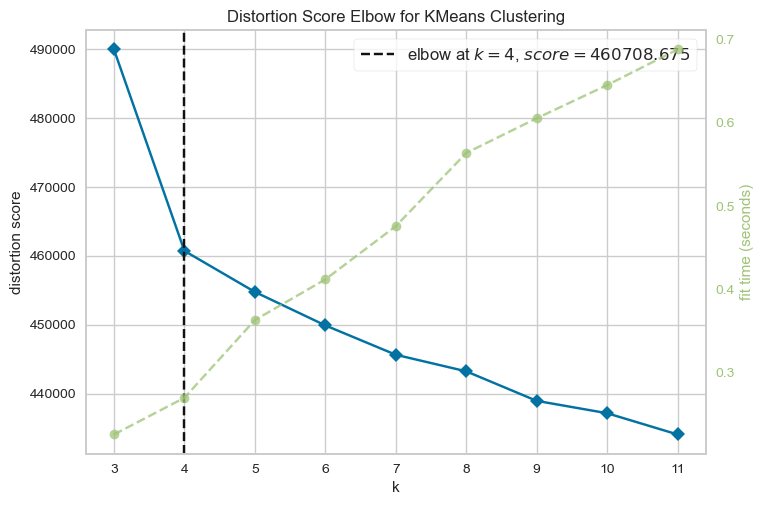

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [73]:
# default distortion
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(3,12))
visualizer.fit(rm)
visualizer.show()

### Silhouette

In [74]:
l = []
for k in range(3, 14):
    km = KMeans(n_clusters=k, random_state=42)
  
    km.fit_predict(rm)

    score = silhouette_score(rm, km.labels_, metric='cosine')
    l.append(score)
  
    print(f'{k} --> Silhouette Score: {score}')

3 --> Silhouette Score: 0.18263111418538408
4 --> Silhouette Score: 0.20267038370977195
5 --> Silhouette Score: 0.15536804588622272
6 --> Silhouette Score: 0.11880149342898971
7 --> Silhouette Score: 0.11044011500931587
8 --> Silhouette Score: 0.09916308619101523
9 --> Silhouette Score: 0.08101804816219181
10 --> Silhouette Score: 0.05300350908650349
11 --> Silhouette Score: 0.07475106659182286
12 --> Silhouette Score: 0.06114226557716531
13 --> Silhouette Score: 0.048589340208090304


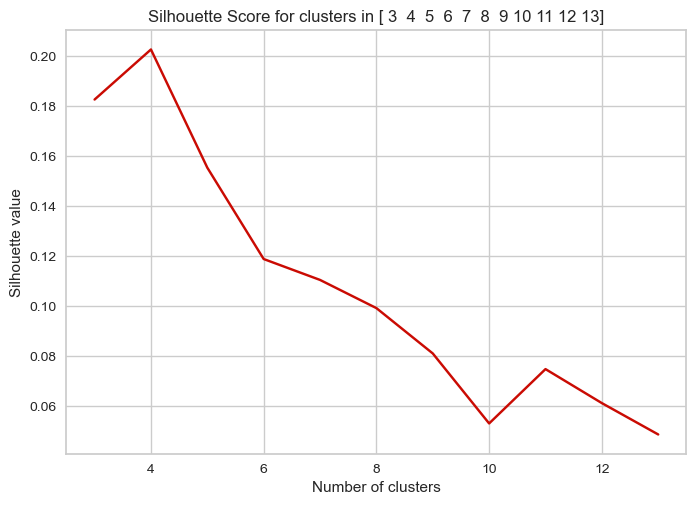

In [75]:
plt.figure()
plt.title(f'Silhouette Score for clusters in {np.arange(3, 14)}')
plt.plot(range(3, 14), l, color='r')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette value')
plt.show()

Utilizzo l'algoritmo kmeans per identificare i clusters

In [76]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rm)
y_kmeans = kmeans.predict(rm)

In [77]:
from collections import Counter

In [78]:
counter = Counter(y_kmeans)

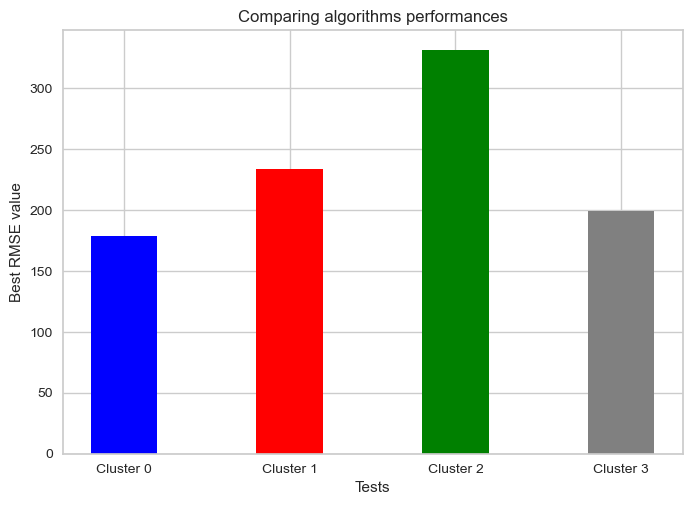

In [79]:
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']
values = [counter.get(0), counter.get(1), counter.get(2), counter.get(3)]
 
# plotting a bar chart
plt.bar(range(1, 5, 1), values, tick_label=labels, width=0.4, color=['blue', 'red', 'green', 'grey'])

plt.xlabel('Tests')
plt.ylabel('Best RMSE value')
plt.title('Comparing algorithms performances')
 
plt.show()

In [80]:
T = preprocessing.Normalizer().fit_transform(rm)
n_clusters = 4

kmeans.fit(T)
centroids, labels = kmeans.cluster_centers_, kmeans.labels_

pca_model = PCA(n_components=2)
pca_model.fit(T)
T = pca_model.transform(T)
centroid_pca = pca_model.transform(centroids)

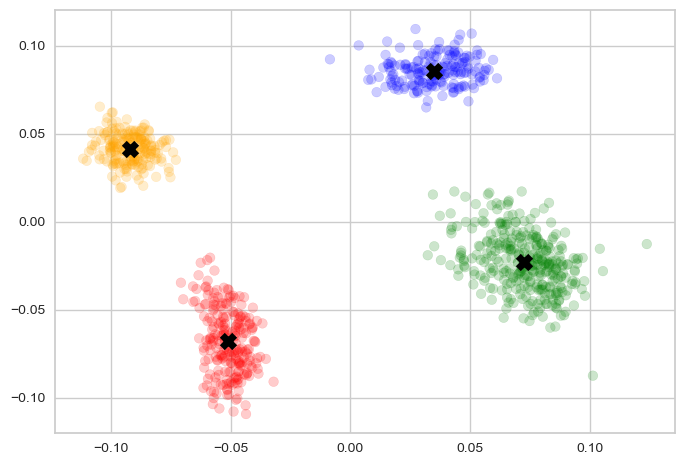

In [81]:
colors = ['blue', 'red', 'green', 'orange']
features_colors = [colors[labels[i]] for i in range(len(T))]

plt.figure()
plt.scatter(T[:, 0], T[:, 1], c=features_colors, marker='o', alpha=0.2)
plt.scatter(centroid_pca[:, 0], centroid_pca[:, 1], marker='x', s=80, linewidths=5, c="black")

plt.show()

___

## K-Means clustering e Rappresentazione matrice di rating
[Indice](#0)

In [93]:
color_map = []
for node in y_kmeans:
    if node == 0:
        color_map.append('orange')
    elif node == 1: 
        color_map.append('red')
    elif node == 2: 
        color_map.append('blue')
    elif node == 3: 
        color_map.append('green')

In [94]:
rat_mat = pd.read_csv('/Users/saraarizzi/jupyter/progetto/final_data/mat_knn_pearson.csv', header=0, index_col=0)
pairwise_mat = pairwise_distances(rat_mat, metric='cosine', n_jobs=-1)
dist_mat = 1 - pairwise_mat

In [95]:
nodes = []
for i in range(0, len(dist_mat)):
    for j in range(i, len(dist_mat)):
        if dist_mat[i][j] > 0.97 and [i+1, j+1] not in nodes and i+1 != j+1:
            nodes.append([i+1, j+1])

In [96]:
unique_node = np.sort(np.unique(list(itertools.chain.from_iterable(nodes))))
print(len(unique_node))
print(len(color_map))

936
943


In [97]:
for i in range(0, 943):
    if i+1 not in unique_node:
        del color_map[i]

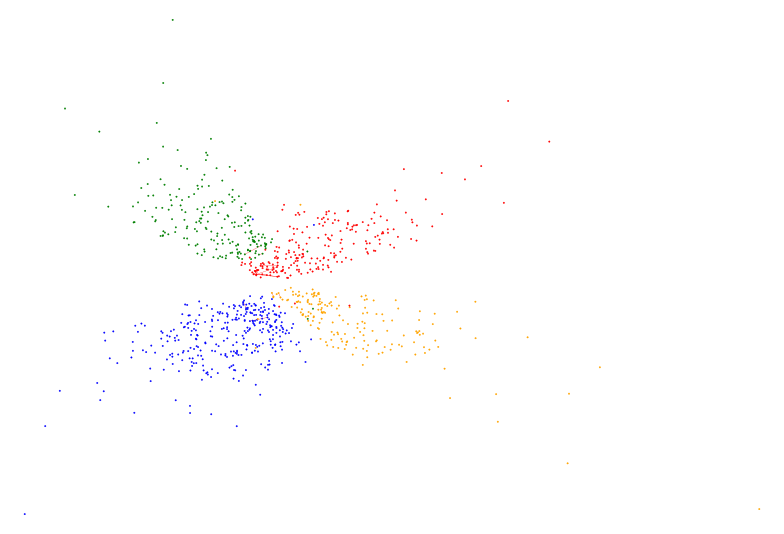

In [98]:
G = nx.Graph()

G.add_nodes_from(unique_node)

for tup in nodes:
    G.add_edge(tup[0], tup[1], weight=dist_mat[tup[0]-1][tup[1]-1])

elarge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] >= 0.9875]

pos = nx.spring_layout(G, seed=7)

n = nx.draw_networkx_nodes(G, pos, node_size=1, nodelist=unique_node, node_color=color_map)

# draw edges
nx.draw_networkx_edges(G, pos, width=.2, edgelist=elarge, edge_color='red', alpha=1)

ax = plt.gca()
ax.margins(0.02)
plt.axis("off")
plt.tight_layout()
plt.savefig('/Users/saraarizzi/jupyter/progetto/full_matrix_colors.pdf')
plt.show()